# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  8322k      0 --:--:--  0:01:48 --:--:-- 6914k--  0:00:04 --:--:-- 28.0M   0 --:--:--  0:00:36 --:--:-- 8380k-  0:01:02 --:--:-- 3841k  9488k      0 --:--:--  0:01:03 --:--:-- 3333k--:--:--  0:01:08 --:--:-- 4464kk      0 --:--:--  0:01:22 --:--:-- 6746k      0 --:--:--  0:01:30 --:--:-- 10.0M-:--:--  0:01:31 --:--:-- 9675k01:40 --:--:-- 5977k


In [4]:
!rm SUSY.csv

In [5]:
!gunzip SUSY.csv.gz

In [6]:
ls -lh

total 5148104
-rw-r--r--@ 1 afarbin  staff   389K Oct 18 13:44 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   5.8M Oct 18 12:45 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   228M Oct 18 12:39 SUSY-small.csv
-rw-r--r--  1 afarbin  staff   2.2G Oct 18 13:43 SUSY.csv


The data is provided as a comma separated file.

In [22]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

head: SUSY.csv: No such file or directory


## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [7]:
!ls -lh

total 5148104
-rw-r--r--@ 1 afarbin  staff   389K Oct 18 13:44 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   5.8M Oct 18 12:45 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   228M Oct 18 12:39 SUSY-small.csv
-rw-r--r--  1 afarbin  staff   2.2G Oct 18 13:43 SUSY.csv


We see that we have 5 million datapoints.

In [5]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [10]:
!head -500000 SUSY.csv > SUSY-small.csv

In [11]:
ls -lh

total 5173504
-rw-r--r--@ 1 afarbin  staff   387K Mar 29 11:08 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   6.1M Mar 18 10:38 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   228M Mar 29 11:09 SUSY-small.csv
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 18 10:38 SUSY.csv


In [12]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [23]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [24]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [25]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [26]:
FeatureNames

['M_Delta_R',
 'dPhi_r_b',
 'cos_theta_r1',
 'MT2',
 'R',
 'S_R',
 'M_R',
 'axial_MET',
 'MET_rel',
 'M_TR_2']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [30]:
filename = "/Users/tanvirsingh/Desktop/pythonlab2/DATA3402.Spring.2026/SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [12]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [31]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


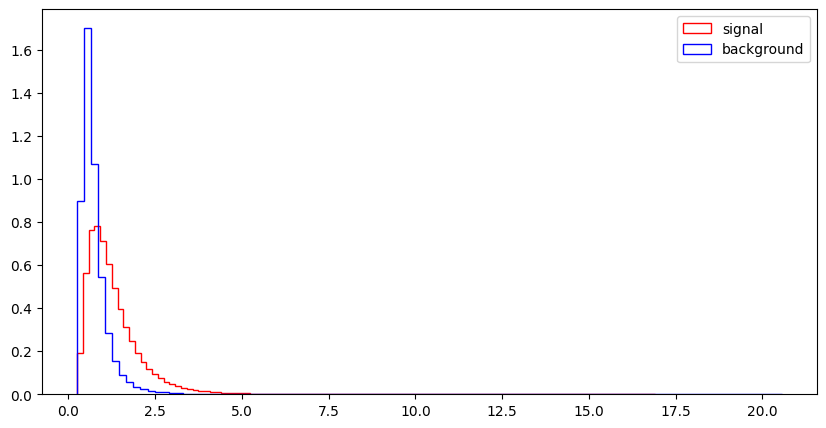

l_1_eta


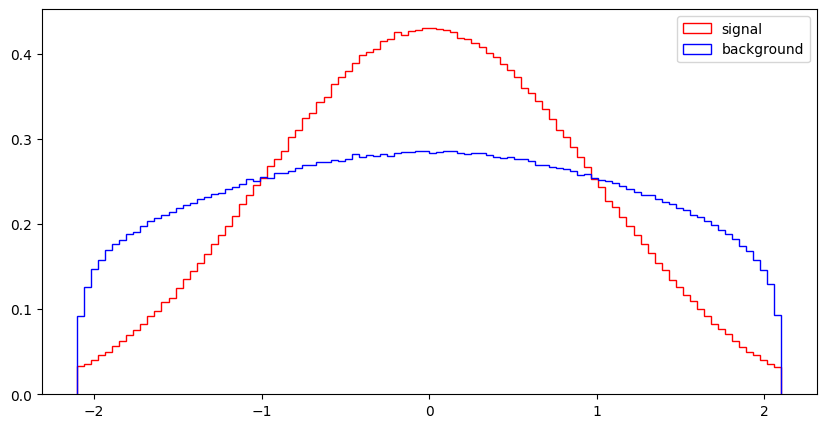

l_1_phi


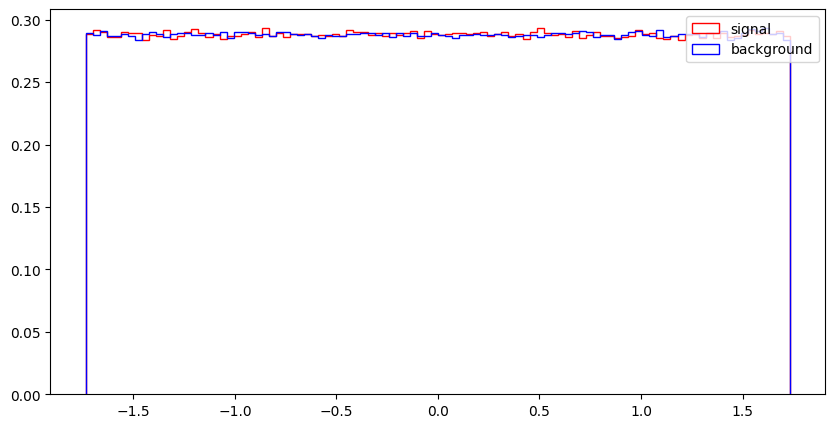

l_2_pT


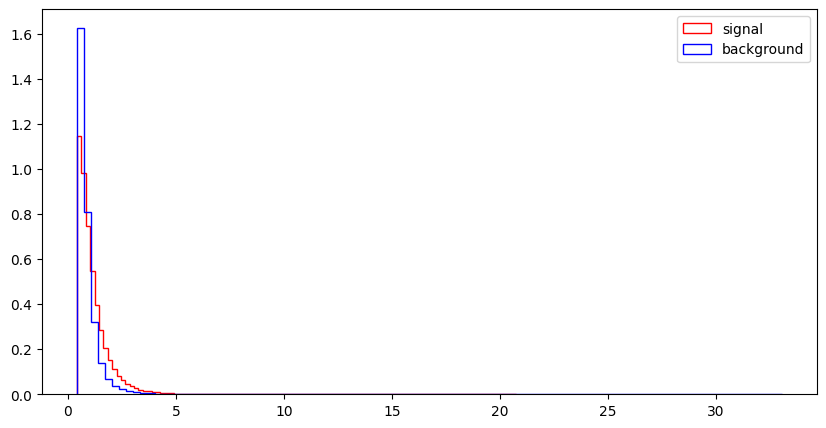

l_2_eta


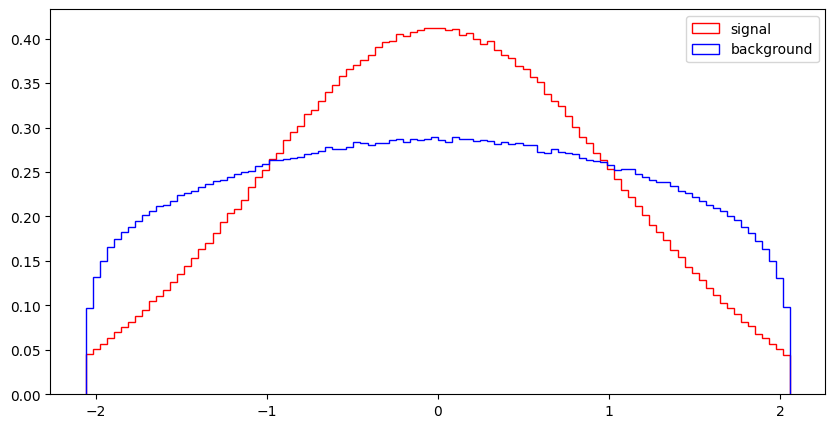

l_2_phi


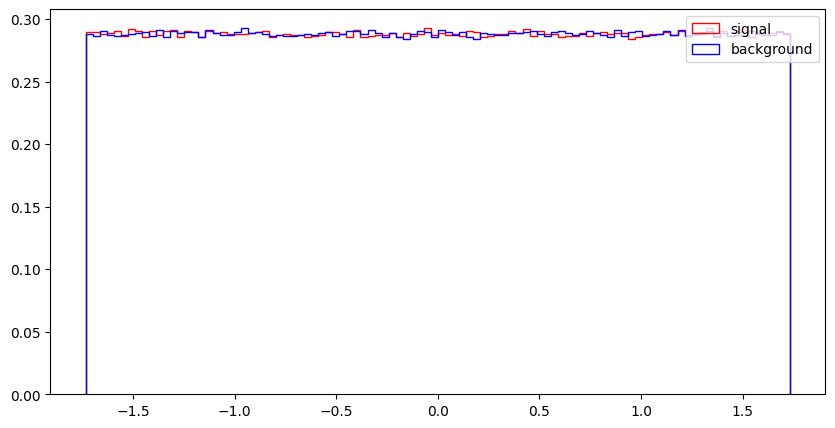

MET


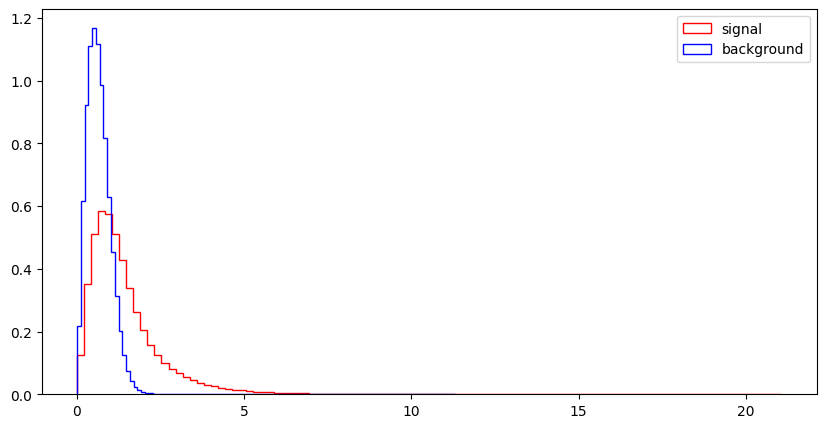

MET_phi


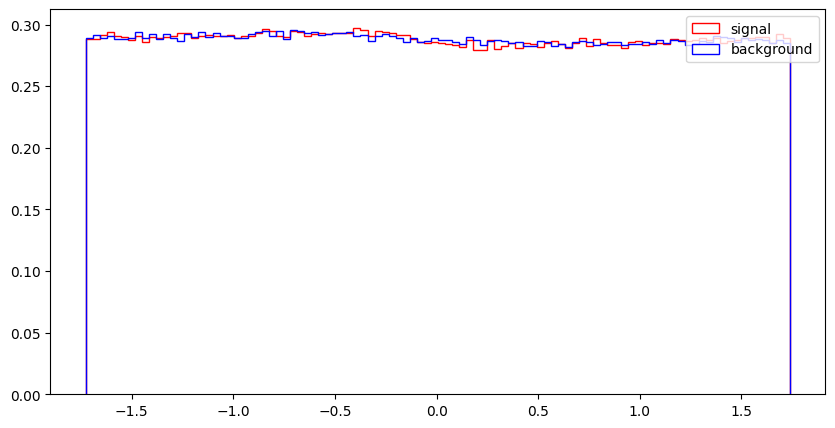

MET_rel


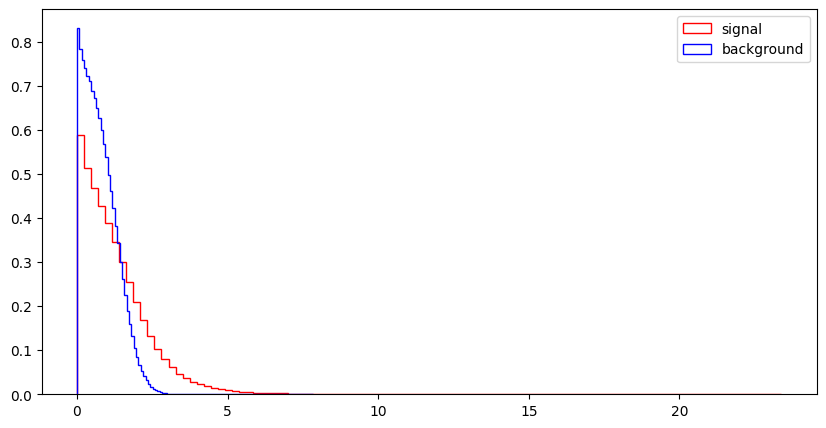

axial_MET


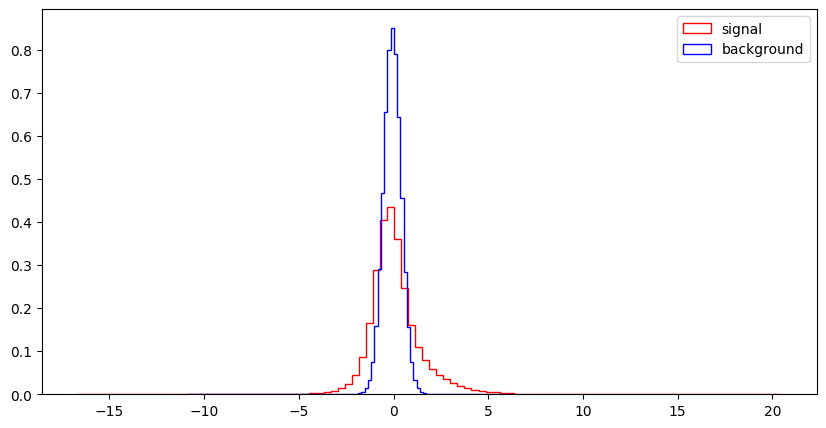

M_R


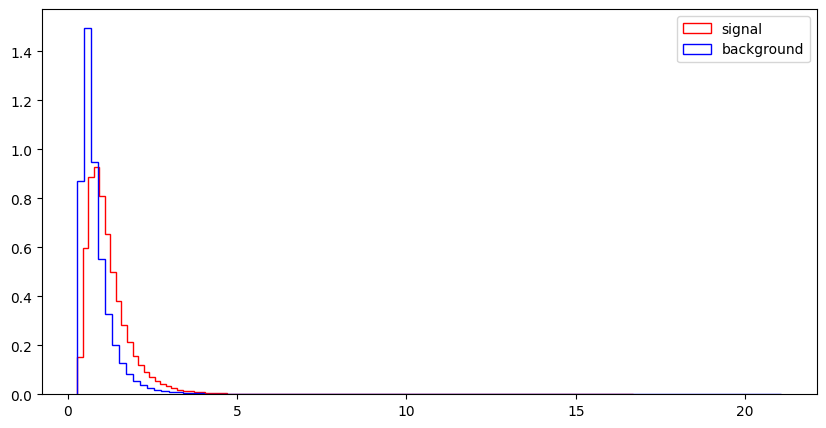

M_TR_2


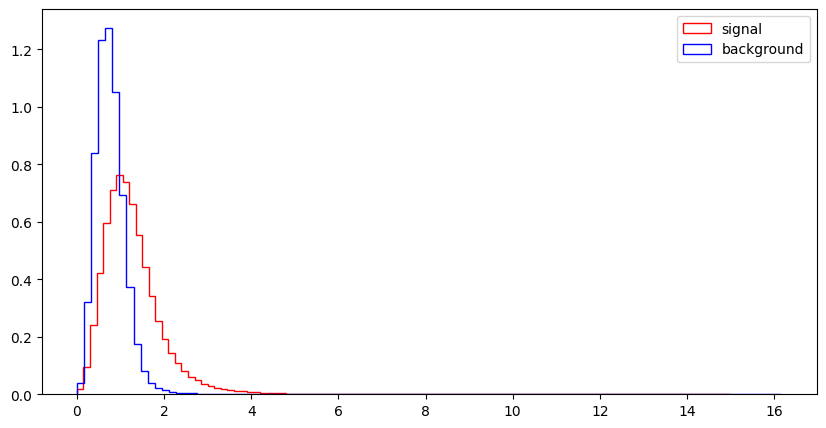

R


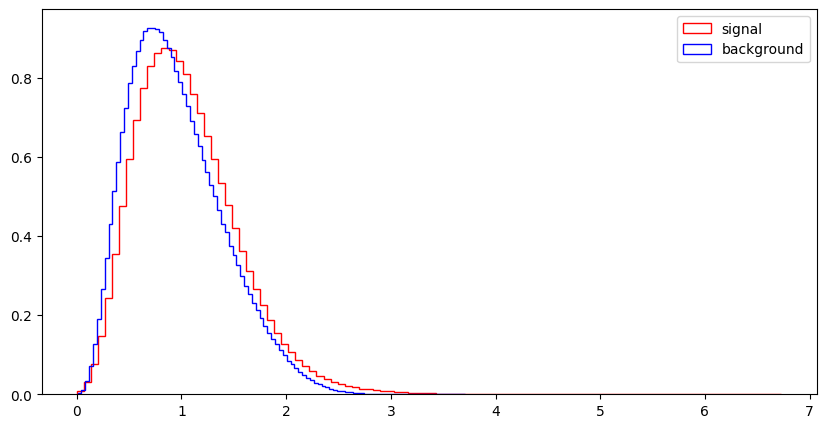

MT2


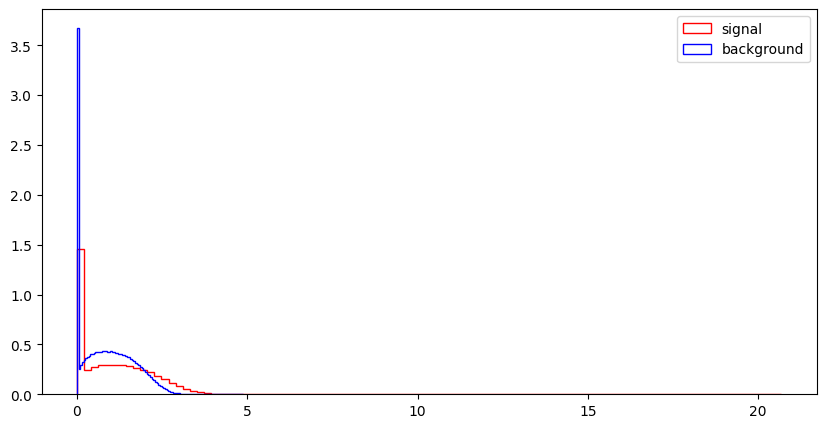

S_R


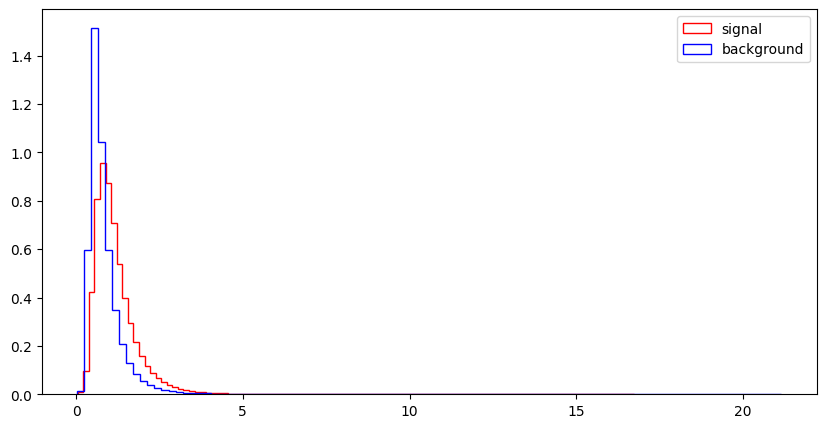

M_Delta_R


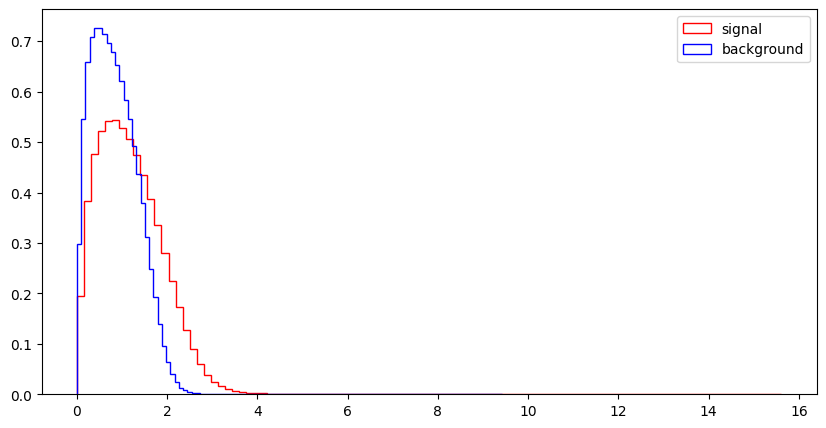

dPhi_r_b


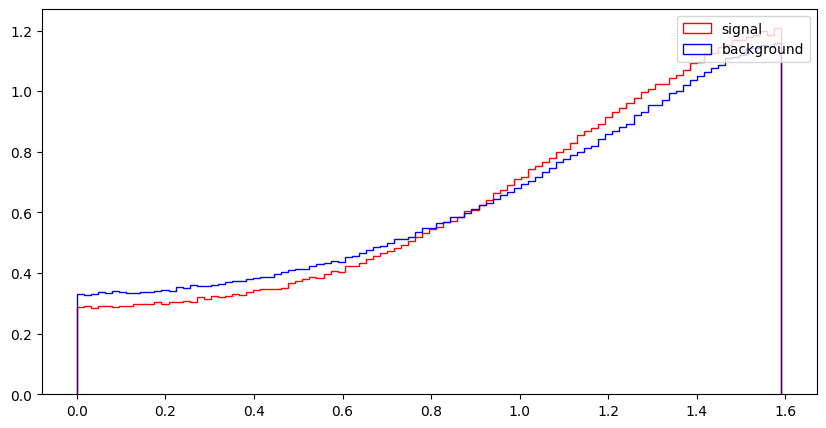

cos_theta_r1


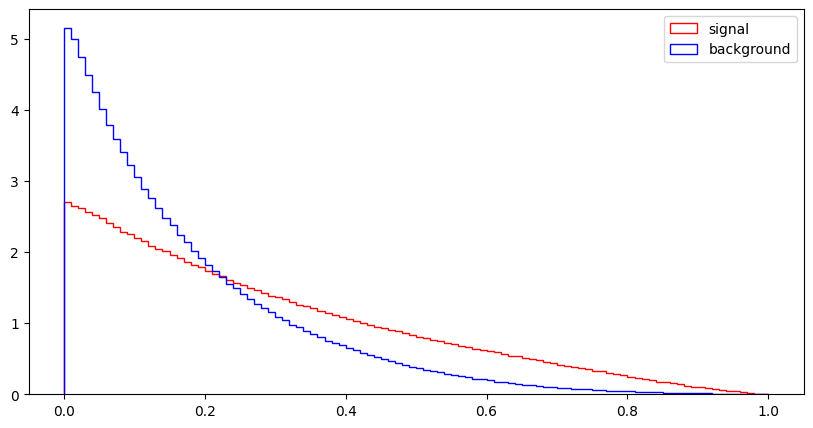

In [32]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

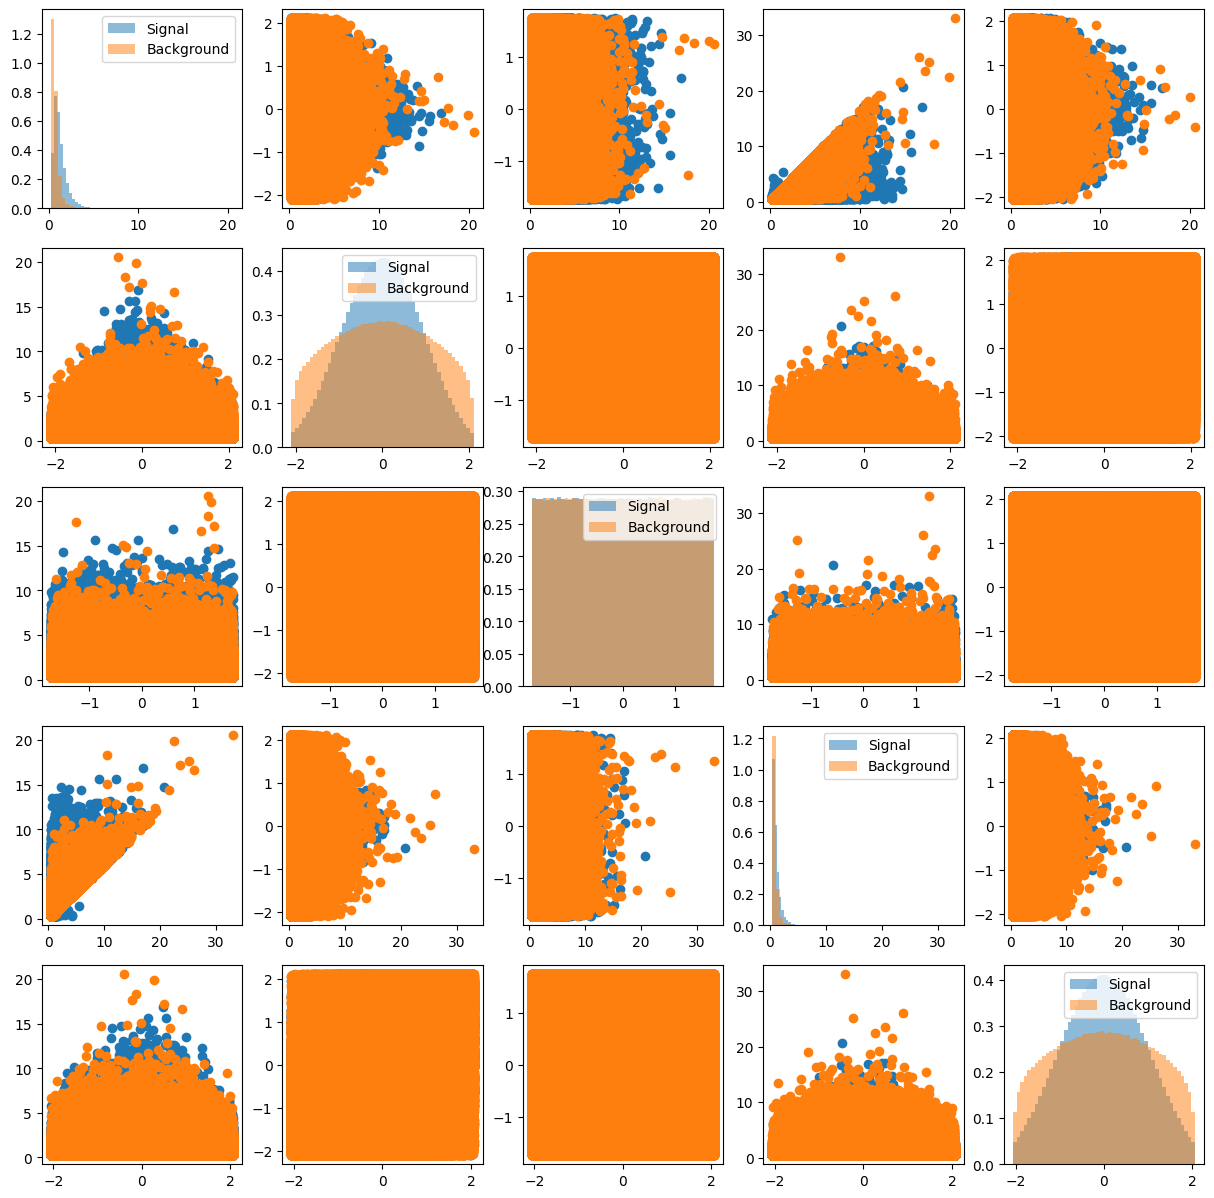

In [63]:
### Part a (From Lecture 13)
columns = df.columns[1:6]
n_columns=len(columns)
plt.figure(figsize=(15,15))

## Needed help with this part since I was not sure what to add in the bracket for "Background"
selection_dict={"Signal":df["signal"]== 1,"Background":df["signal"]== 0}

def compare_distributions(df,column_name,selections,**kwargs):
    for label,selection in selections.items():        
        _=plt.hist(df[selection][column_name],label=label,**kwargs)

    _=plt.legend()

def compare_scatter(df,x_var_name,y_var_name,selections,make_legend=True) :
    for label,selection in selections.items():   
        _=plt.scatter(df[selection][x_var_name],df[selection][y_var_name],label=label)

plot_i=0
for i,x_var_name in enumerate(columns):
    for j,y_var_name in enumerate(columns):
        plot_i+=1
        plt.subplot(n_columns,n_columns,plot_i)
        make_legend = plot_i==1
        if i==j:
            compare_distributions(df,x_var_name,
                     selection_dict,
                     alpha=0.5,
                     density=1,
                     bins=50,
                     )
        else:
            compare_scatter(df,x_var_name,y_var_name,selection_dict,make_legend=make_legend)

In [35]:
### Part B (with AI assistance)
# Split the dataset to avoid repeatedly filtering the full data set using loops
signal_df = df[df["signal"] == 1]
background_df = df[df["signal"] == 0]

# Dictionary used to store the split data to make plotting easier
data_dict = {"Signal": signal_df, "Background": background_df}

# Similar to Lecture 13, this is used to plot histograms
def compare_distributions_fast(data_dict, column_name, **kwargs):
    for label, data in data_dict.items():
        plt.hist(data[column_name], label=label, **kwargs)
    plt.legend()

# Simplified this by using less parameters
def compare_scatter(x_var_name,y_var_name):
    # Use dictionary of split data
    # s=1 reduces marker size for larger datasets (makes rendering faster)
    # alpha=0.3 improves visability in dense areas
    for label, data in data_dict.items():   
        plt.scatter(data[x_var_name],data[y_var_name],s=1,alpha=0.3,label=label)


def pair_plot(columns, data_dict, title):

    # Kept the same as in Lecture 13
    n_columns = len(columns)
    plt.figure(figsize=(20, 20))
    plot_i=0

    for i,x_var_name in enumerate(columns):
        for j,y_var_name in enumerate(columns):
            plot_i+=1
            plt.subplot(n_columns,n_columns,plot_i)
        
            if i==j:
                compare_distributions_fast(
                        data_dict, 
                        x_var_name,
                        alpha=0.5,
                        bins=50,
                        density=True
                        )
            else:
                compare_scatter(x_var_name, y_var_name)
            # Remove axis ticks for cleaner visualization grid
            plt.xticks([])
            plt.yticks([])

    plt.suptitle(title, fontsize=16)
    # Reduce overlap between subplots
    plt.tight_layout()
    plt.show()
    # Close figure to free memory
    plt.close()

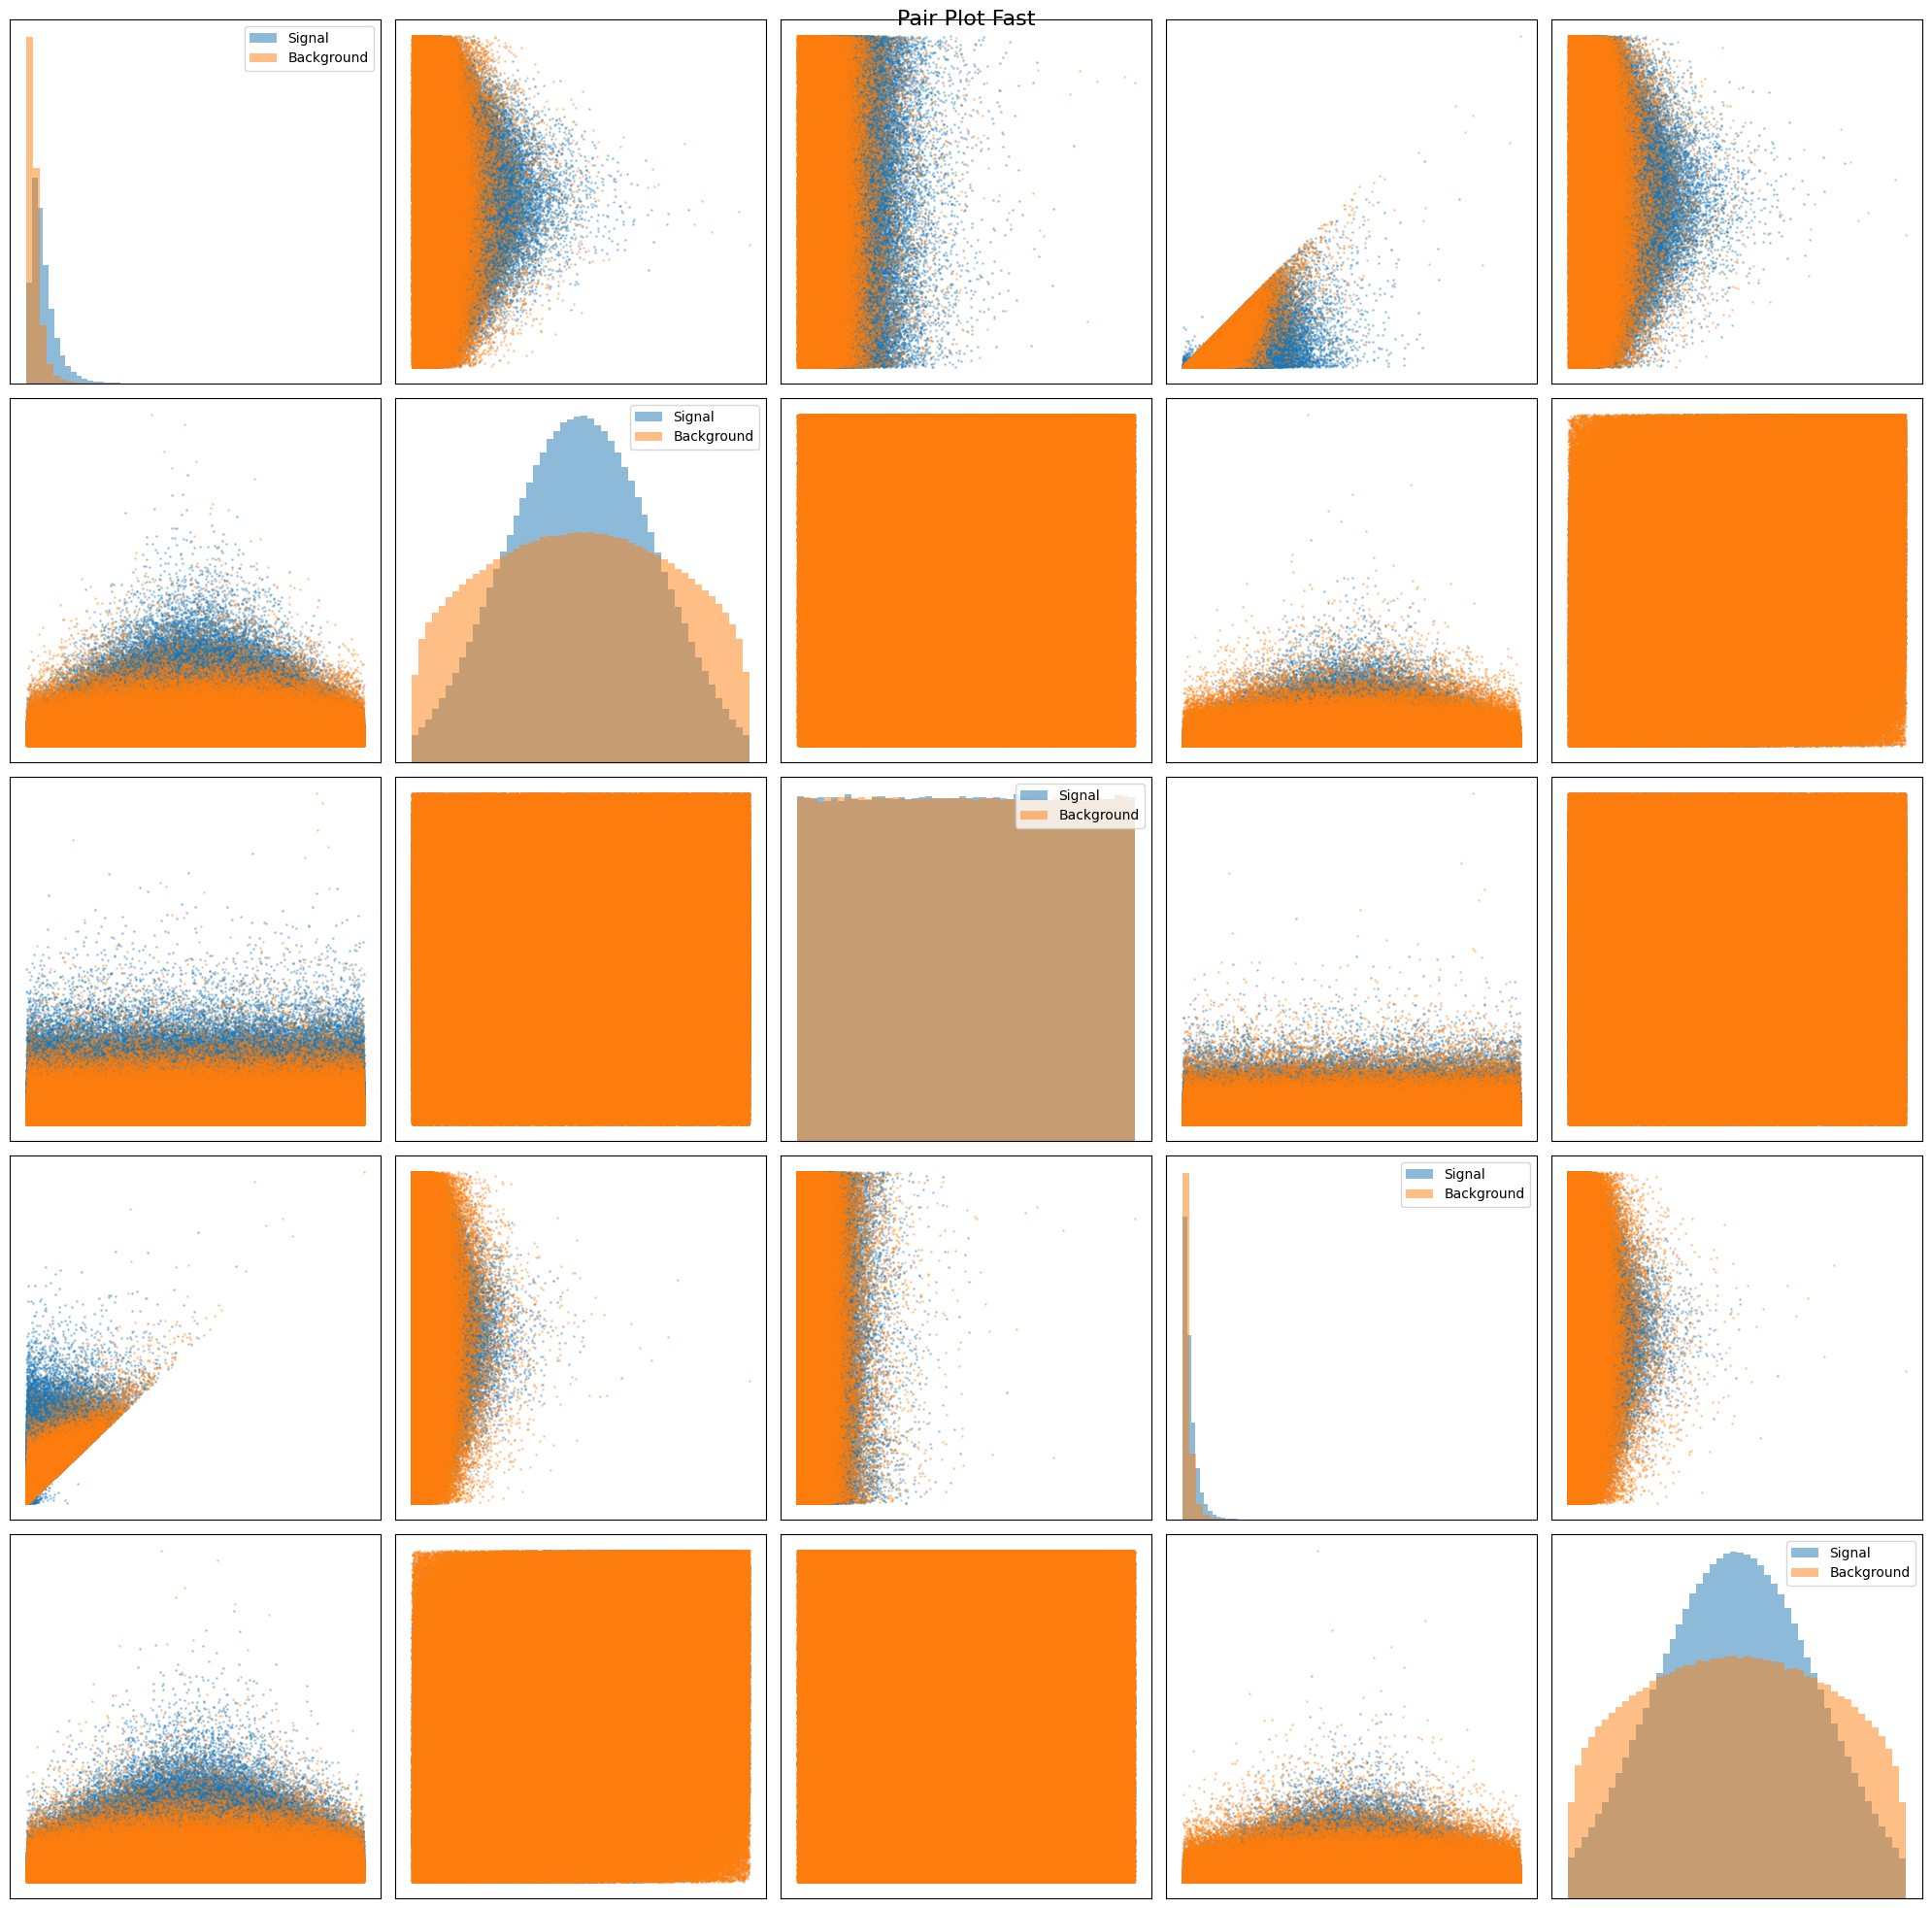

In [36]:
pair_plot(columns, data_dict, "Pair Plot Fast")

To display the pair plots faster, I mainly reduced the use of loops within the code and made a dictionary of the split data.

Part C:
The best observables for separating signal from background are those whose distributions show clear differences between the two classes. In the histograms, the background distributions are generally more spread out, while the signal distributions tend to be more concentrated with sharper peaks. In addition, scatter plots of these variables show partial separation between signal and background events, where the signal and background occupy different regions of feature space. This indicates that these observables are useful for distinguishing between the two classes.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [37]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [38]:
### Part B (with AI assistance)
import numpy as np

# Define low-level physics features
low_level = ["l_1_pT", "l_1_eta", "l_1_phi","l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi"]
# Define high-level physics features
high_level = ["MET_rel", "axial_MET", "M_R", "M_TR_2","R", "MT2", "S_R", "M_Delta_R","dPhi_r_b", "cos_theta_r1"]
# Combine both feature sets for comparison
all_features = low_level + high_level

# Extract feature matrices from the dataframe
# .values converts to NumPy arrays for numerical computation
X_all = df[all_features].values
X_low = df[low_level].values
X_high = df[high_level].values

# Compute covariance matrices
# Covariance measures how variables vary together
# rowvar=False ensures columns are treated as variables
cov_all = np.cov(X_all, rowvar=False)
cov_low = np.cov(X_low, rowvar=False)
cov_high = np.cov(X_high, rowvar=False)


# Compute correlation matrices
# Correlation standardizes covariance to range [-1, 1]
# Useful for comparing strength of relationships between features
corr_all = np.corrcoef(X_all, rowvar=False)
corr_low = np.corrcoef(X_low, rowvar=False)
corr_high = np.corrcoef(X_high, rowvar=False)

print("Covariance matrix (low-level):")
print(cov_low)

print("Correlation matrix (low-level):")
print(corr_low)

print("Covariance matrix (high-level):")
print(cov_high)

print("Correlation matrix (high-level):")
print(corr_high)

print("Covariance matrix (all-features):")
print(cov_all)

print("Correlation matrix (all-features):")
print(corr_all)

Covariance matrix (low-level):
[[ 4.72428126e-01 -2.62666897e-04 -2.29060618e-04  3.07887443e-01
  -3.02456872e-04  2.27164310e-04  2.30950772e-01 -6.76375484e-04]
 [-2.62666897e-04  1.00622400e+00  3.21599952e-04 -3.77895911e-04
   4.05877394e-01  2.97083862e-04 -5.57684419e-04 -5.40623754e-04]
 [-2.29060618e-04  3.21599952e-04  1.00334220e+00 -1.28546630e-04
   6.41115931e-04 -2.68130132e-01  1.20012378e-03 -1.84183886e-01]
 [ 3.07887443e-01 -3.77895911e-04 -1.28546630e-04  4.28003791e-01
  -4.54288205e-04  1.14725700e-04  7.97039608e-02 -1.38807284e-03]
 [-3.02456872e-04  4.05877394e-01  6.41115931e-04 -4.54288205e-04
   1.00568572e+00 -6.47265749e-05  5.11898819e-05 -1.25591734e-04]
 [ 2.27164310e-04  2.97083862e-04 -2.68130132e-01  1.14725700e-04
  -6.47265749e-05  1.00326487e+00  4.32091479e-06 -3.44683883e-02]
 [ 2.30950772e-01 -5.57684419e-04  1.20012378e-03  7.97039608e-02
   5.11898819e-05  4.32091479e-06  7.61932857e-01 -1.62175466e-03]
 [-6.76375484e-04 -5.40623754e-04 -1.8

In [64]:
### Part C (with AI assistance)
import pandas as pd

# Convert covariance matrix for low-level features into a labeled DataFrame
# Rows and columns are labeled with feature names for easier interpretation
cov_low_df = pd.DataFrame(cov_low, index=low_level, columns=low_level)

# Print a formatted version of the covariance matrix for low-level features
# round(4) limits values to 4 decimal places for readability
# tabulate is used to display the matrix in a clean table format
print("Low-Level Covariance Matrix")
print(tabulate.tabulate(cov_low_df.round(4), headers="keys", tablefmt="fancy_grid"))

# Convert low-level correlation matrix into a labeled DataFrame
# Correlation values are easier to compare across features than covariance
corr_low_df = pd.DataFrame(corr_low, index=low_level, columns=low_level)

# Print formatted correlation matrix for low-level features
print("Low-Level Correlation Matrix")
print(tabulate.tabulate(corr_low_df.round(4), headers="keys", tablefmt="fancy_grid"))

# Convert high-level covariance matrix into a labeled DataFrame
# High-level features are engineered physics variables designed for better separation
cov_high_df = pd.DataFrame(cov_high, index=high_level, columns=high_level)

# Print formatted covariance matrix for high-level features
print("High-Level Covariance Matrix")
print(tabulate.tabulate(cov_high_df.round(4), headers="keys", tablefmt="fancy_grid"))

corr_high_df = pd.DataFrame(corr_high, index=high_level, columns=high_level)

# Print formatted correlation matrix for high-level features
print("High-Level Correlation Matrix")
print(tabulate.tabulate(corr_high_df.round(4), headers="keys", tablefmt="fancy_grid"))

Low-Level Covariance Matrix
╒═════════╤══════════╤═══════════╤═══════════╤══════════╤═══════════╤═══════════╤═════════╤═══════════╕
│         │   l_1_pT │   l_1_eta │   l_1_phi │   l_2_pT │   l_2_eta │   l_2_phi │     MET │   MET_phi │
╞═════════╪══════════╪═══════════╪═══════════╪══════════╪═══════════╪═══════════╪═════════╪═══════════╡
│ l_1_pT  │   0.4724 │   -0.0003 │   -0.0002 │   0.3079 │   -0.0003 │    0.0002 │  0.231  │   -0.0007 │
├─────────┼──────────┼───────────┼───────────┼──────────┼───────────┼───────────┼─────────┼───────────┤
│ l_1_eta │  -0.0003 │    1.0062 │    0.0003 │  -0.0004 │    0.4059 │    0.0003 │ -0.0006 │   -0.0005 │
├─────────┼──────────┼───────────┼───────────┼──────────┼───────────┼───────────┼─────────┼───────────┤
│ l_1_phi │  -0.0002 │    0.0003 │    1.0033 │  -0.0001 │    0.0006 │   -0.2681 │  0.0012 │   -0.1842 │
├─────────┼──────────┼───────────┼───────────┼──────────┼───────────┼───────────┼─────────┼───────────┤
│ l_2_pT  │   0.3079 │   -0.0004 │  

In [39]:
### Part D (with AI assistance)
def matrix_table(df, columns, kind="cov"):
    # Extract selected columns from the dataframe and convert to NumPy array
    X = df[columns].values

    # Loop that chooses which type of matrix to compute based on the input parameter
    if kind == "cov":
        mat = np.cov(X, rowvar=False)
        title = "Covariance Matrix"
    else:
        mat = np.corrcoef(X, rowvar=False)
        title = "Correlation Matrix"

    print("\n" + title)
    
    # Convert matrix into a labeled DataFrame for readability
    # Then format it into a clean table using tabulate
    print(tabulate.tabulate(
        pd.DataFrame(mat, index=columns, columns=columns),
        headers="keys",
        tablefmt="fancy_grid",
        floatfmt=".3f"
))
    
    return mat

matrix_table(df, low_level, kind="cov")
matrix_table(df, low_level, kind="corr")
matrix_table(df, high_level, kind="cov")
matrix_table(df, high_level, kind="corr")
matrix_table(df, all_features, kind="cov")
matrix_table(df, all_features, kind="corr")


Covariance Matrix
╒═════════╤══════════╤═══════════╤═══════════╤══════════╤═══════════╤═══════════╤════════╤═══════════╕
│         │   l_1_pT │   l_1_eta │   l_1_phi │   l_2_pT │   l_2_eta │   l_2_phi │    MET │   MET_phi │
╞═════════╪══════════╪═══════════╪═══════════╪══════════╪═══════════╪═══════════╪════════╪═══════════╡
│ l_1_pT  │    0.472 │    -0.000 │    -0.000 │    0.308 │    -0.000 │     0.000 │  0.231 │    -0.001 │
├─────────┼──────────┼───────────┼───────────┼──────────┼───────────┼───────────┼────────┼───────────┤
│ l_1_eta │   -0.000 │     1.006 │     0.000 │   -0.000 │     0.406 │     0.000 │ -0.001 │    -0.001 │
├─────────┼──────────┼───────────┼───────────┼──────────┼───────────┼───────────┼────────┼───────────┤
│ l_1_phi │   -0.000 │     0.000 │     1.003 │   -0.000 │     0.001 │    -0.268 │  0.001 │    -0.184 │
├─────────┼──────────┼───────────┼───────────┼──────────┼───────────┼───────────┼────────┼───────────┤
│ l_2_pT  │    0.308 │    -0.000 │    -0.000 │    0.42

array([[ 1.00000000e+00, -3.80969436e-04, -3.32703994e-04,
         6.84699951e-01, -4.38797801e-04,  3.29962378e-04,
         3.84940135e-01, -9.82431075e-04,  1.61097983e-01,
        -1.81743312e-02,  8.51601617e-01,  7.24394441e-01,
        -1.83190335e-01, -2.16362271e-02,  8.11652530e-01,
         2.28772577e-01, -1.56878203e-01,  1.66310861e-01],
       [-3.80969436e-04,  1.00000000e+00,  3.20069358e-04,
        -5.75838965e-04,  4.03474773e-01,  2.95681343e-04,
        -6.36916975e-04, -5.38058992e-04, -5.56196068e-04,
        -4.95181701e-04, -4.88455266e-04, -4.53809073e-04,
         2.70457946e-04, -1.82868790e-04, -4.51966057e-04,
        -8.05723346e-04,  1.82076368e-04,  7.37624650e-04],
       [-3.32703994e-04,  3.20069358e-04,  1.00000000e+00,
        -1.96160856e-04,  6.38235397e-04, -2.67247271e-01,
         1.37259732e-03, -1.83573166e-01,  1.71469279e-03,
        -1.95829899e-03, -3.17025665e-04,  1.43188097e-03,
         1.85827580e-03,  2.03797800e-03,  7.23090499e

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

5.1: From the pair plots, different observables require different selection criteria:

- Variables such as l_1_pT, l_2_pT, MET, M_R, MT2, and S_R show signal distributions shifted toward higher values compared to background, so the optimal selection is x > x_c.

- Variables such as l_1_eta, l_2_eta, and cos_theta_r1 are more concentrated around central values for signal, while background is more spread out. For these, the optimal selection is |x - μ| < x_c.

- Some variables show little separation and are not useful for selection. In the pair plots, there would just be a big blob of orange.

In [40]:
### 5.2 (with AI assistance)
def get_efficiencies(df, feature, label, thresholds, mode="greater"):
    # Split dataset into signal and background based on label column
    # Signal = label 1, Background = label 0
    signal = df[df[label] == 1][feature].values
    background = df[df[label] == 0][feature].values

    # Lists to store True Positive Rate (TPR) and False Positive Rate (FPR)
    tpr = []
    fpr = []

    # Loop over all threshold values to evaluate classification performance
    for t in thresholds:
        # Different thresholding strategies depending on feature behavior
        if mode == "greater":
            sig_pass = np.sum(signal > t)
            bkg_pass = np.sum(background > t)

        elif mode == "less":
            sig_pass = np.sum(signal < t)
            bkg_pass = np.sum(background < t)

        elif mode == "abs_less":
            sig_pass = np.sum(np.abs(signal) < t)
            bkg_pass = np.sum(np.abs(background) < t)

        elif mode == "abs_greater":
            sig_pass = np.sum(np.abs(signal) > t)
            bkg_pass = np.sum(np.abs(background) > t)

        # Compute signal efficiency (TPR)
        tpr.append(sig_pass / len(signal))

        # Compute background efficiency (FPR)
        fpr.append(bkg_pass / len(background))

    # Return arrays for plotting or analysis
    return np.array(tpr), np.array(fpr)

def plot_tpr_fpr(df, feature, label, mode="greater"):
    # Create a range of thresholds spanning the observed values of features
    thresholds = np.linspace(df[feature].min(), df[feature].max(), 100)

    # Compute TPR and FPR using function
    tpr, fpr = get_efficiencies(df, feature, label, thresholds, mode)

    plt.plot(thresholds, tpr, label="TPR (Signal Efficiency)")
    plt.plot(thresholds, fpr, label="FPR (Background Efficiency)")
    plt.xlabel(feature)
    plt.ylabel("Efficiency")
    plt.title(f"TPR & FPR vs Cut: {feature}")
    plt.legend()
    plt.show()

    return thresholds, tpr, fpr

In [41]:
### 5.3 (with AI assistance)
def significance(tpr, fpr, N_S, N_B):
    # Convert efficiencies into expected number of events after applying the cut
    # Np_S = number of signal events that pass the threshold
    # Np_B = number of background events that pass the threshold
    Np_S = tpr * N_S
    Np_B = fpr * N_B

    # Compute statistical significance (signal over sqrt(signal + background))
    return Np_S / np.sqrt(Np_S + Np_B)

def plot_significance(df, feature, label, N_S, N_B, mode="greater"):
    # Generate a range of threshold values spanning the feature distribution
    thresholds = np.linspace(df[feature].min(), df[feature].max(), 100)

    # Compute signal efficiency (TPR) and background efficiency (FPR) for each threshold
    tpr, fpr = get_efficiencies(df, feature, label, thresholds, mode)
    
    # Convert efficiencies into significance values across thresholds
    sig = significance(tpr, fpr, N_S, N_B)

    plt.plot(thresholds, sig)
    plt.xlabel(feature)
    plt.ylabel("Significance")
    plt.title(f"Significance vs Cut: {feature} (N_S={N_S}, N_B={N_B})")
    plt.show()

    return thresholds, sig


===== Feature: l_1_pT (greater) =====


/var/folders/6t/2jhf471114v5c23mm3_tc1_r0000gn/T/ipykernel_65961/2577500999.py:6: RuntimeWarning: invalid value encountered in divide
  return Np_S / np.sqrt(Np_S + Np_B)


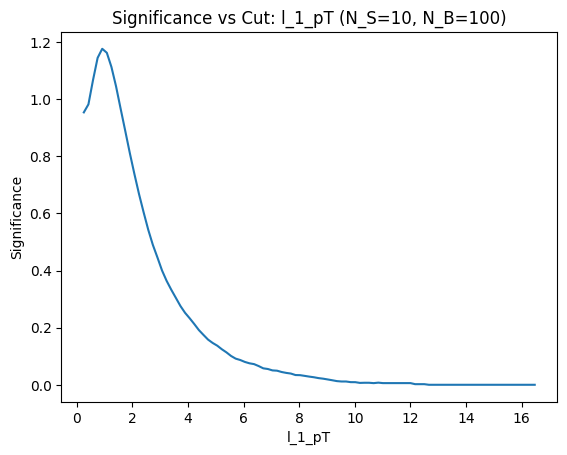

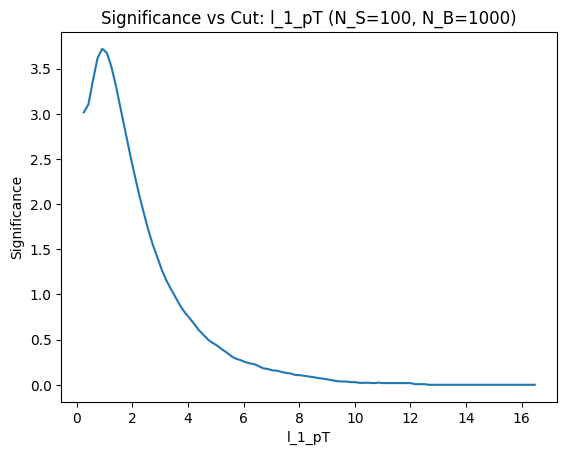

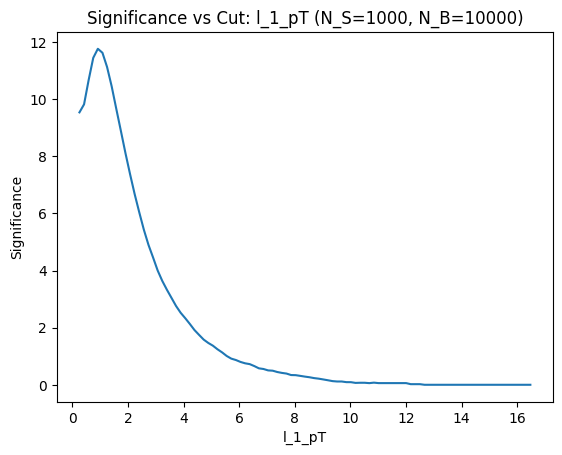

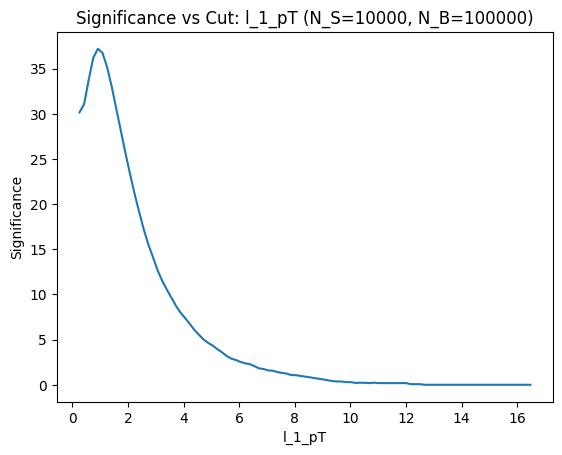


===== Feature: l_2_pT (greater) =====


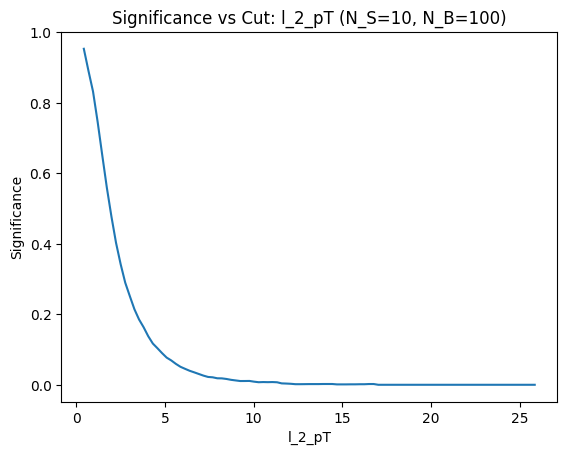

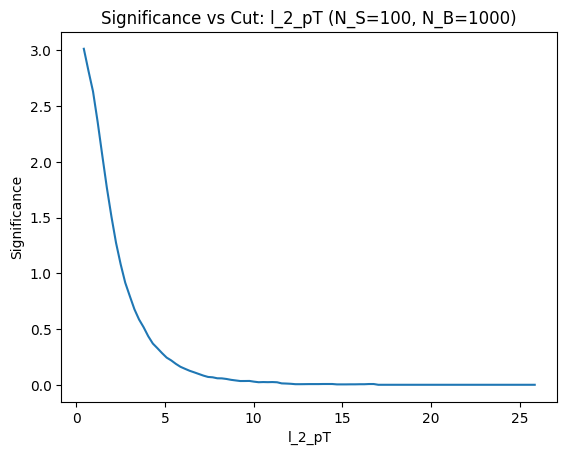

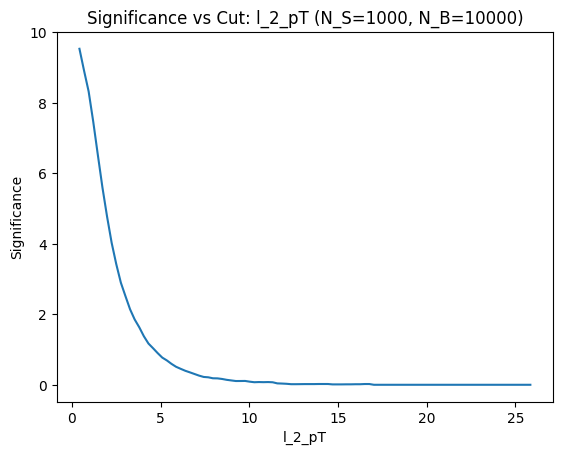

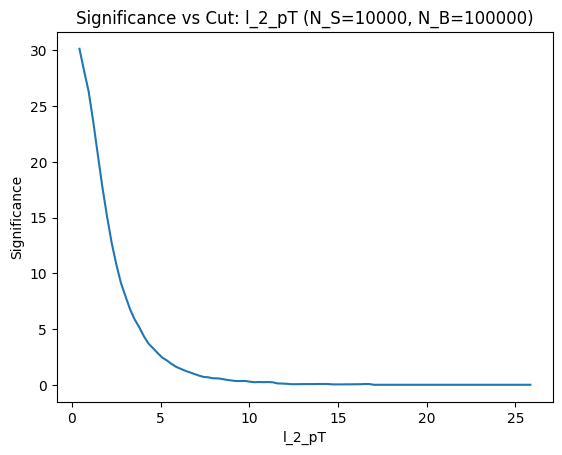


===== Feature: MET (greater) =====


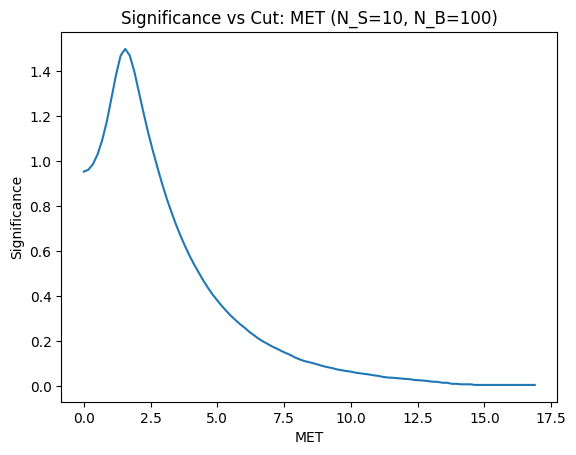

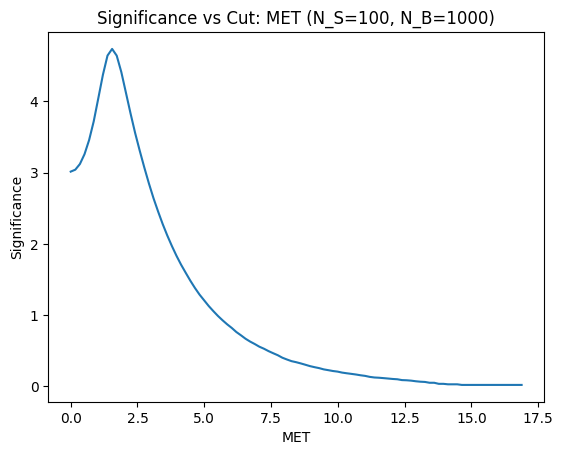

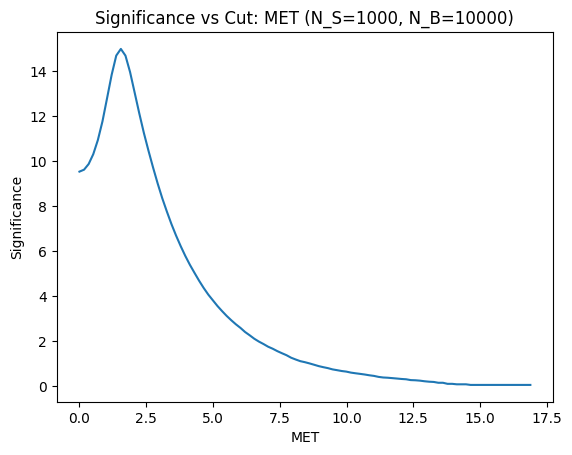

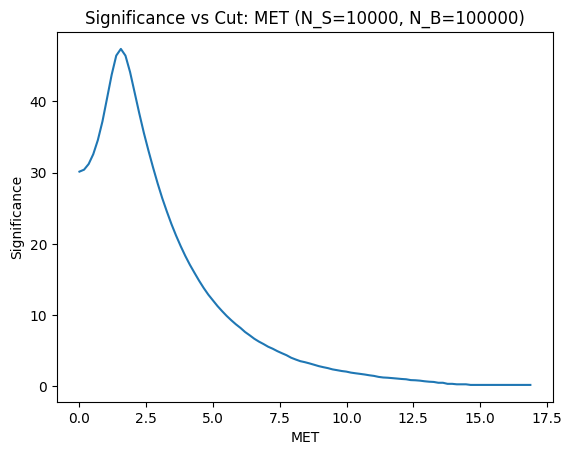


===== Feature: M_R (greater) =====


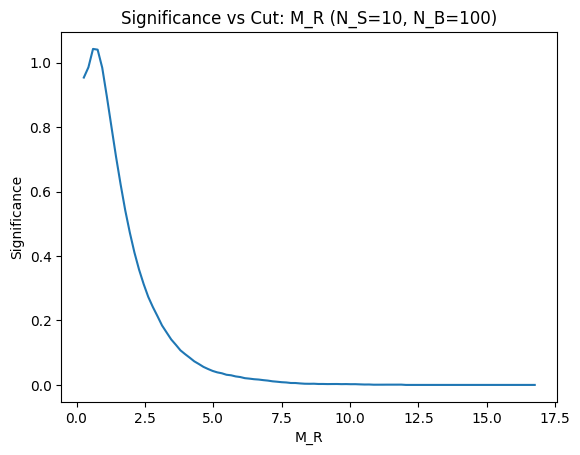

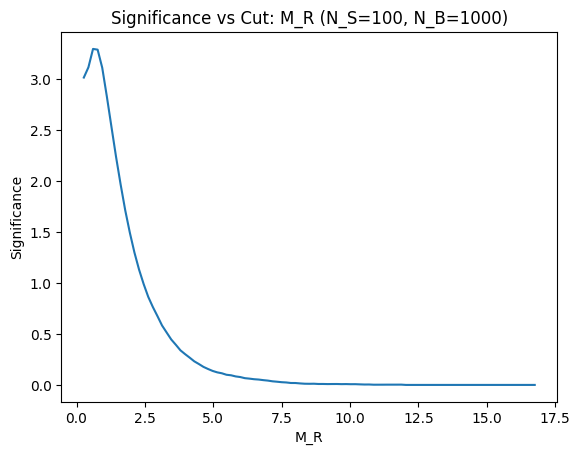

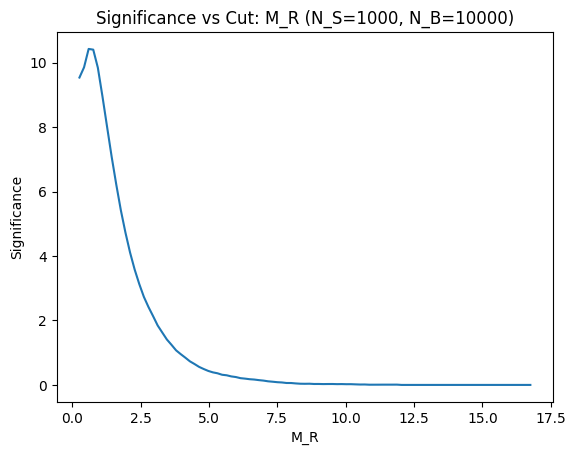

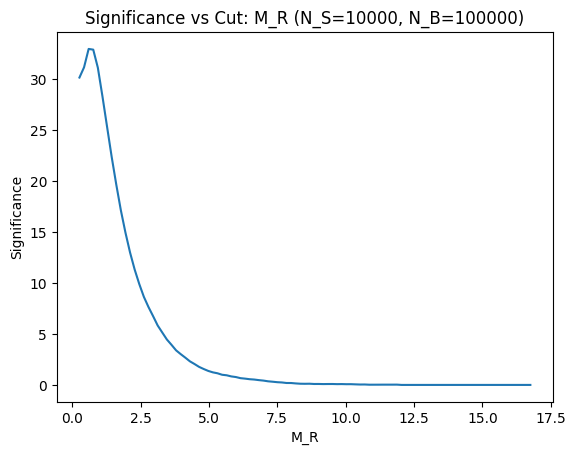


===== Feature: MT2 (greater) =====


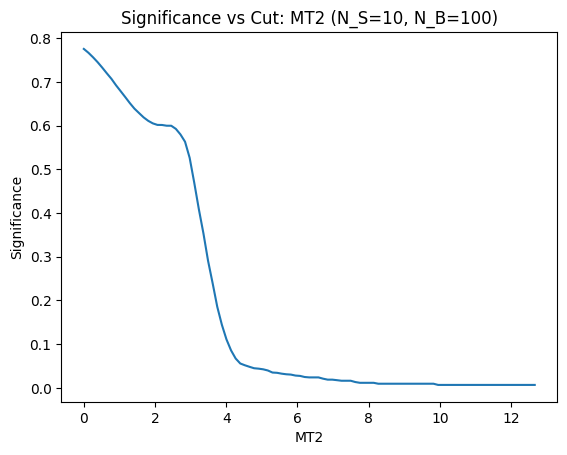

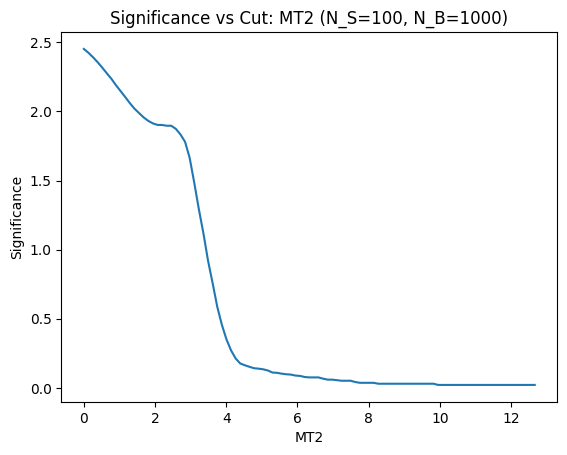

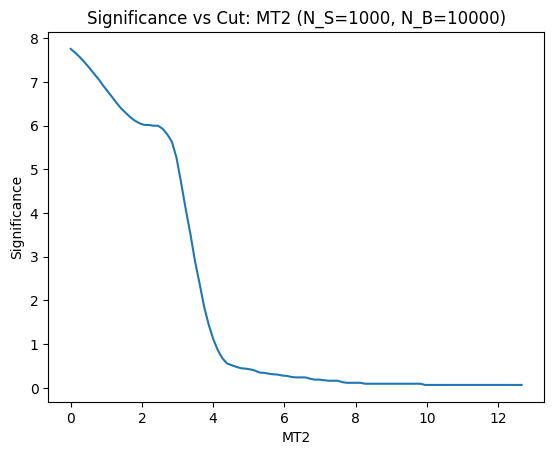

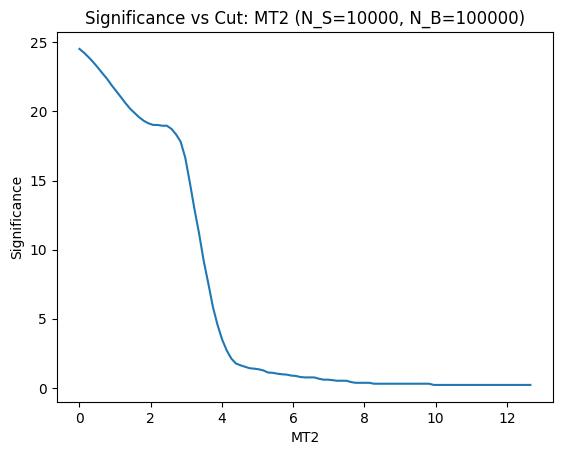


===== Feature: S_R (greater) =====


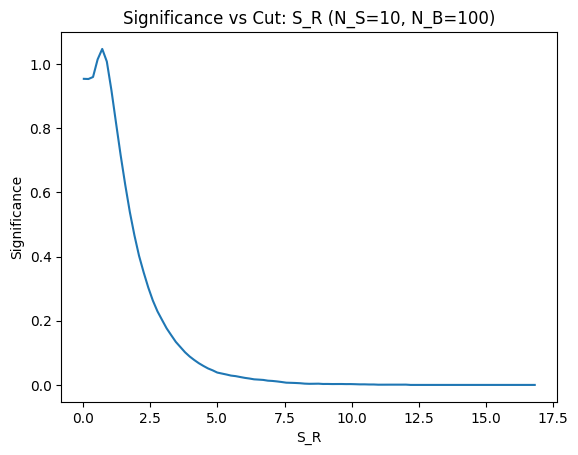

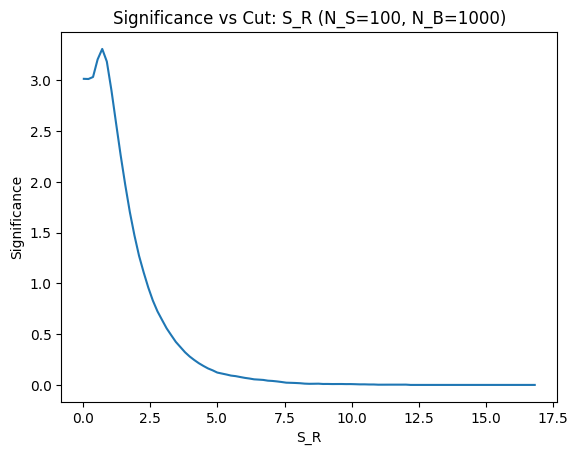

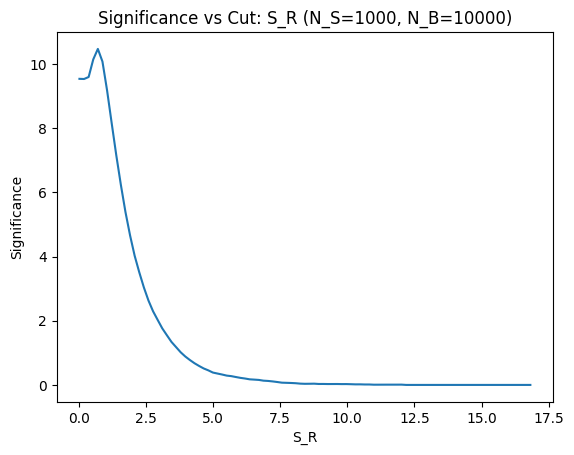

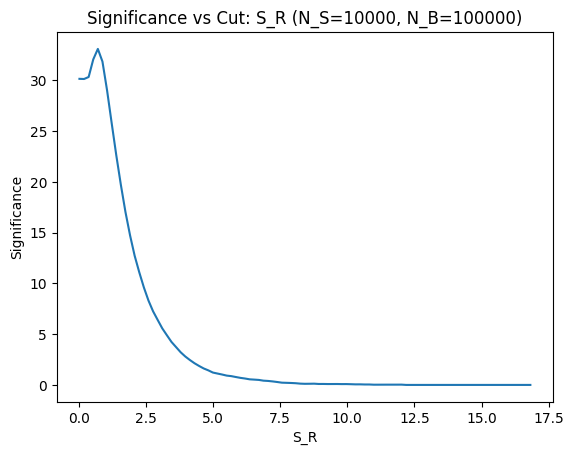


===== Feature: l_1_eta (abs_less) =====


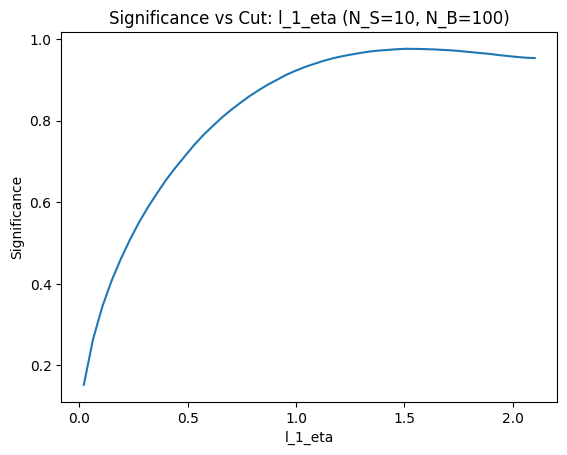

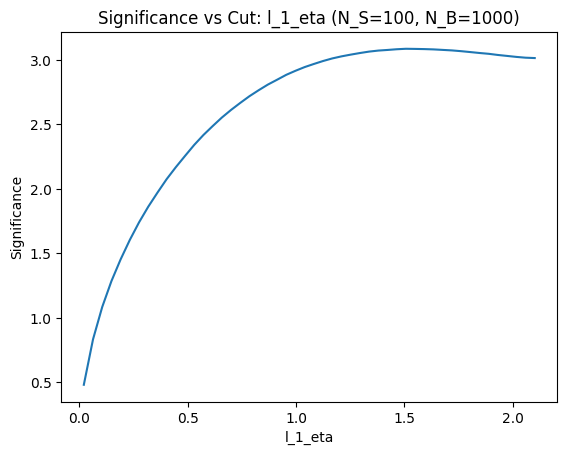

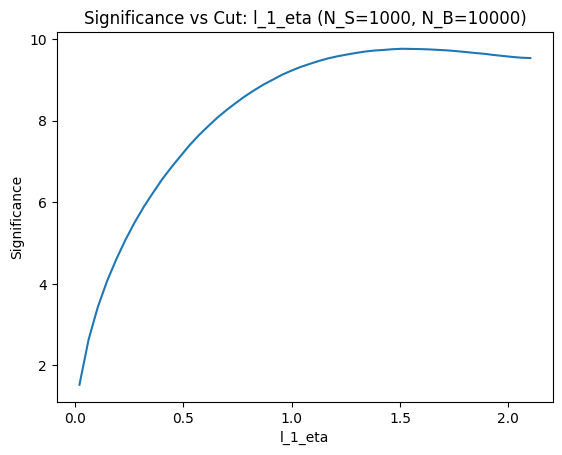

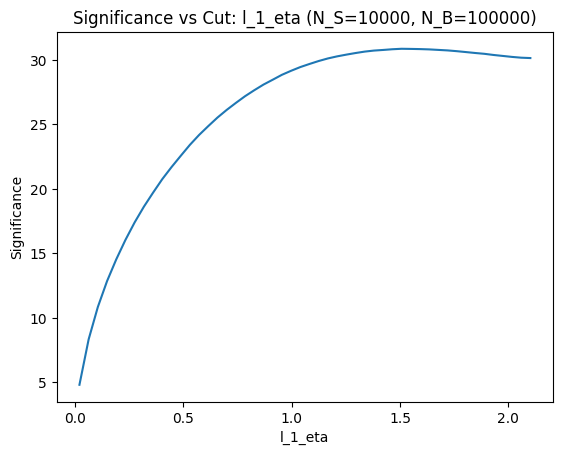


===== Feature: l_2_eta (abs_less) =====


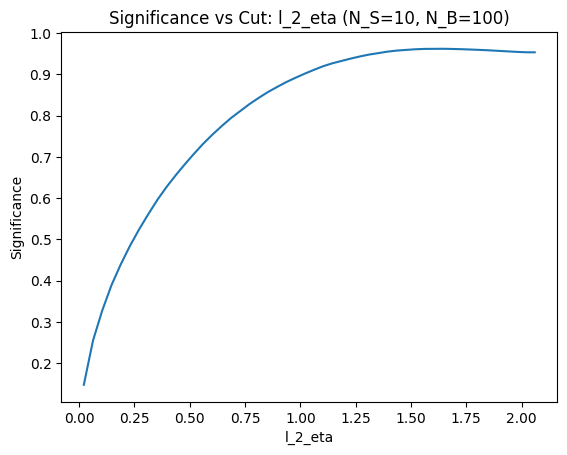

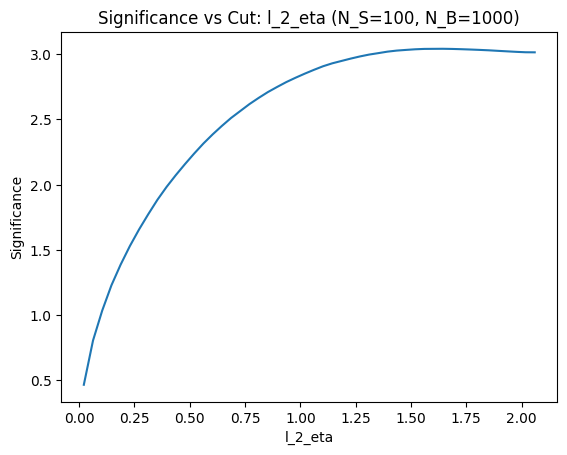

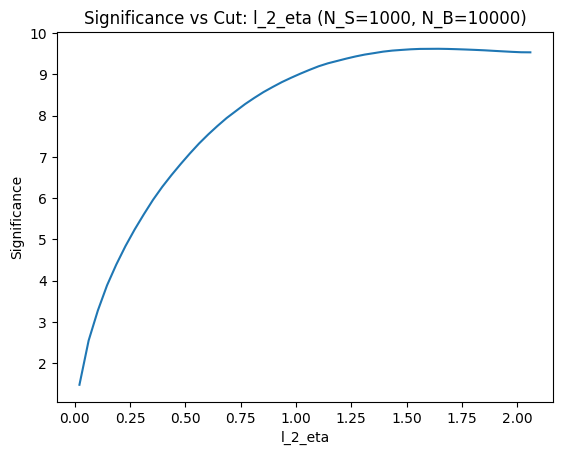

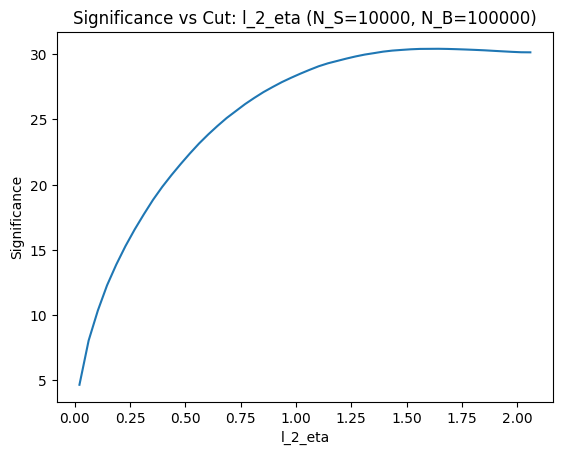


===== Feature: cos_theta_r1 (abs_less) =====


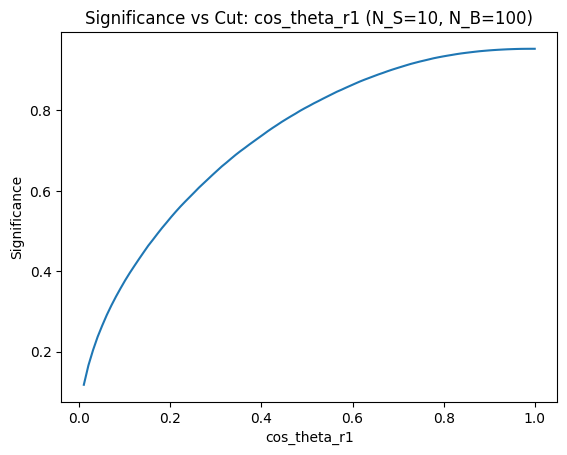

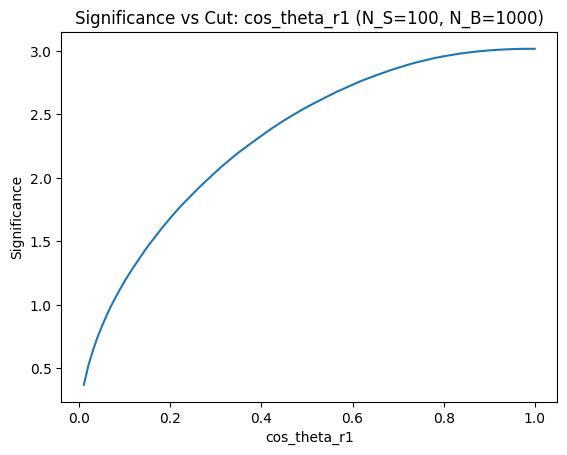

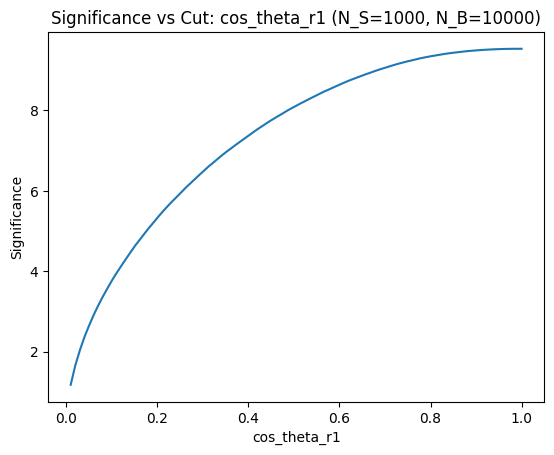

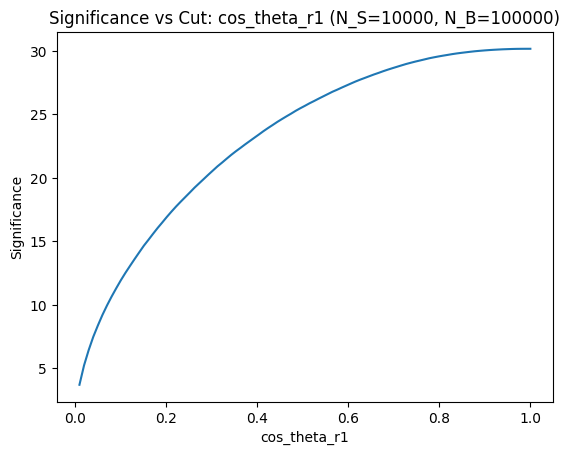

In [91]:
### Run
scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

feature_modes = {
    "l_1_pT": "greater",
    "l_2_pT": "greater",
    "MET": "greater",
    "M_R": "greater",
    "MT2": "greater",
    "S_R": "greater",
    "l_1_eta": "abs_less",
    "l_2_eta": "abs_less",
    "cos_theta_r1": "abs_less"
}

for feature, mode in feature_modes.items():
    print(f"\n===== Feature: {feature} ({mode}) =====")

    for N_S, N_B in scenarios:
        plot_significance(df, feature, "signal", N_S, N_B, mode=mode)

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




6.1: I selected the observables M_R, MT2, and MET based on how they stood out in the pair plots and significance curves. The cut values x_c are chosen near the peaks of the significance plots for each observable.

In [42]:
### 6.2 (with AI assistance)

# Define features to apply selection cuts on
# Each tuple contains (feature_name, cut_type)
# cut_type determines whether values are kept above/below threshold
selected_features = [
    ("M_R", "greater"),
    ("MT2", "greater"),
    ("MET", "greater")
]

# Define cutoff values for each feature
# These represent the threshold values used in the selection
cut_values = {
    "M_R": 0.6,
    "MT2": 0.5,
    "MET": 0.4
}

def cut_flow(df, features, cut_values, N_S, N_B):
    # Create a copy of the dataframe to avoid modifying original data
    df_cut = df.copy()

    # Results stored
    results = []

    for feature, mode in features:
        xc = cut_values[feature]

        # Apply cut
        if mode == "greater":
            df_cut = df_cut[df_cut[feature] > xc]
        elif mode == "less":
            df_cut = df_cut[df_cut[feature] < xc]
        elif mode == "abs_less":
            df_cut = df_cut[np.abs(df_cut[feature]) < xc]
        elif mode == "abs_greater":
            df_cut = df_cut[np.abs(df_cut[feature]) > xc]

        # Count remaining signal and background events after cuts
        S = np.sum(df_cut["signal"] == 1)
        B = np.sum(df_cut["signal"] == 0)

        # Compute efficiencies relative to original dataset
        eps_S = S / np.sum(df["signal"] == 1)
        eps_B = B / np.sum(df["signal"] == 0)

        # Scale efficiencies to expected event counts
        Np_S = eps_S * N_S
        Np_B = eps_B * N_B

        # Compute statistical significance (avoid dividing by zero)
        sigma = Np_S / np.sqrt(Np_S + Np_B) if (Np_S + Np_B) > 0 else 0

        results.append([
            feature, xc, eps_S, eps_B, Np_S, Np_B, sigma
        ])

    headers = ["Cut", "x_c", "ε_S", "ε_B", "N'_S", "N'_B", "sigma"]

    print(tabulate.tabulate(results, headers=headers, floatfmt=".3f", tablefmt="fancy_grid"))

    return results

scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

for N_S, N_B in scenarios:
    print(f"\n===== Scenario: N_S={N_S}, N_B={N_B} =====")
    cut_flow(df, selected_features, cut_values, N_S, N_B)


===== Scenario: N_S=10, N_B=100 =====
╒═══════╤═══════╤═══════╤═══════╤════════╤════════╤═════════╕
│ Cut   │   x_c │   ε_S │   ε_B │   N'_S │   N'_B │   sigma │
╞═══════╪═══════╪═══════╪═══════╪════════╪════════╪═════════╡
│ M_R   │ 0.600 │ 0.874 │ 0.620 │  8.739 │ 62.026 │   1.039 │
├───────┼───────┼───────┼───────┼────────┼────────┼─────────┤
│ MT2   │ 0.500 │ 0.539 │ 0.400 │  5.392 │ 39.956 │   0.801 │
├───────┼───────┼───────┼───────┼────────┼────────┼─────────┤
│ MET   │ 0.400 │ 0.510 │ 0.341 │  5.099 │ 34.146 │   0.814 │
╘═══════╧═══════╧═══════╧═══════╧════════╧════════╧═════════╛

===== Scenario: N_S=100, N_B=1000 =====
╒═══════╤═══════╤═══════╤═══════╤════════╤═════════╤═════════╕
│ Cut   │   x_c │   ε_S │   ε_B │   N'_S │    N'_B │   sigma │
╞═══════╪═══════╪═══════╪═══════╪════════╪═════════╪═════════╡
│ M_R   │ 0.600 │ 0.874 │ 0.620 │ 87.389 │ 620.263 │   3.285 │
├───────┼───────┼───────┼───────┼────────┼─────────┼─────────┤
│ MT2   │ 0.500 │ 0.539 │ 0.400 │ 53.915 │ 399.

6.3: From the correlation matrices, variables such as M_R and S_R are highly correlated. Because they carry similar information, applying cuts on both can be redundant and may remove signal events without greatly improving background rejection.

To address this, we apply a cut on one variable first (for example, M_R) and then adjust the cut on another variable (such as MET). This helps improve the overall significance compared to using fixed, independent cuts.

Changing the order of cuts affects the result because once a selection is applied, the distribution of remaining events changes. As a result, optimizing cuts step by step can give better results than choosing all cuts separately at the start.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



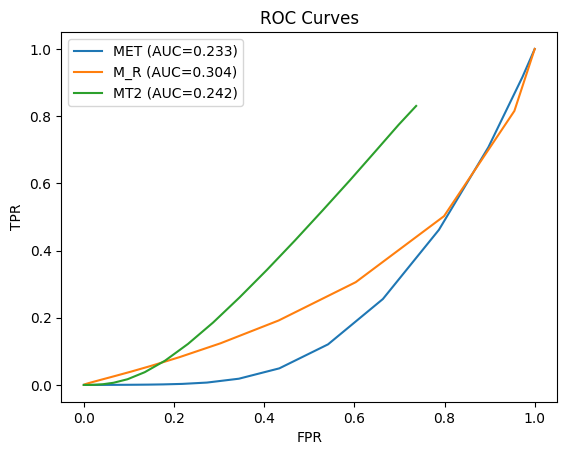

In [43]:
### 7.1 (with AI assistance)
def plot_roc(df, feature, label, mode="greater"):
    # Create a range of threshold values across the feature distribution
    thresholds = np.linspace(df[feature].min(), df[feature].max(), 300)

    # Compute True Positive Rate (TPR) and False Positive Rate (FPR) for each threshold
    tpr, fpr = get_efficiencies(df, feature, label, thresholds, mode)

    plt.plot(fpr, tpr, label=feature)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title(f"ROC Curve: {feature}")
    plt.legend()
    plt.show()

    return fpr, tpr

def plot_multiple_roc(df, features, label, mode="greater"):
    plt.figure()

    # Loop through each feature and compute its ROC curve
    for feature in features:
        fpr, tpr = get_efficiencies(
            df, feature, label,
            np.linspace(df[feature].min(), df[feature].max(), 100),
            mode
        )
        # Sort values by FPR to ensure correct AUC calculation
        order = np.argsort(fpr)

        # Compute Area Under Curve (AUC) using trapezoidal rule
        auc = np.trapezoid(tpr[order], fpr[order])

        # Plot ROC curve with AUC shown in label
        plt.plot(fpr, tpr, label=f"{feature} (AUC={auc:.3f})")

    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Curves")
    plt.legend()
    plt.show()

features = ["MET", "M_R", "MT2"]  
plot_multiple_roc(df, features, label="signal", mode="greater")

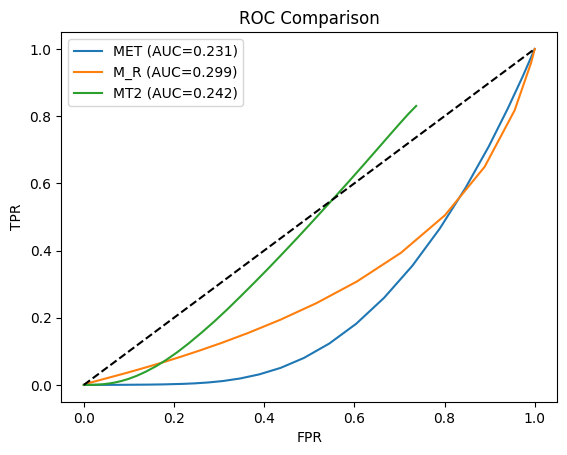

In [65]:
### 7.2 (with AI assistance)
def roc_plot(df, features, label, mode="greater", n_thresholds=200):

    # Create a new figure for plotting multiple ROC curves
    plt.figure()

    # Loop through each feature and compute its ROC curve
    for feature in features:

        # Create evenly spaced threshold values across the feature range
        thresholds = np.linspace(
            df[feature].min(),
            df[feature].max(),
            n_thresholds
        )

        # Compute FPR and TPR
        fpr, tpr = get_efficiencies(df, feature, label, thresholds, mode)

        # Convert lists to NumPy arrays for easier numerical operations
        fpr = np.array(fpr)
        tpr = np.array(tpr)

        # Sort values by FPR to ensure correct ROC curve ordering
        idx = np.argsort(fpr)
        fpr, tpr = fpr[idx], tpr[idx]

        # Compute AUC using trapezoidal rule
        auc = np.trapezoid(tpr, fpr)

        plt.plot(fpr, tpr, label=f"{feature} (AUC={auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Comparison")
    plt.legend()
    plt.show()

features = ["MET", "M_R", "MT2"]

roc_plot(df, features, label="signal", mode="greater")

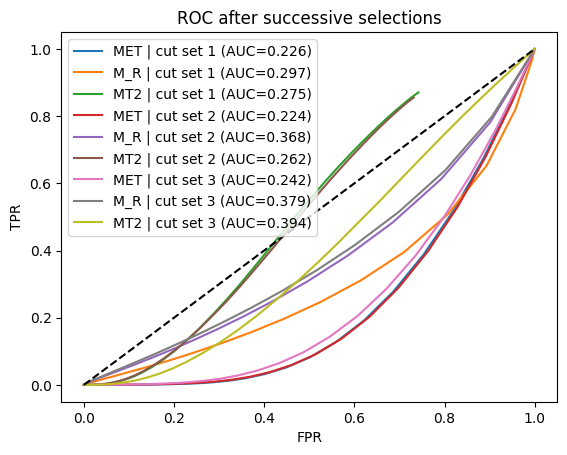

In [44]:
### 7.3 (with AI assistance)
def auc_manual(x, y):
    # Convert inputs to NumPy arrays for numerical operations
    x = np.array(x)
    y = np.array(y)

    # Sort values by x-axis to ensure correct integration order
    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]

    # Compute AUC using trapezoidal rule manually
    # This approximates the integral of y with respect to x
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2)

def roc_after_cuts(df, cut_sequences, label="signal", mode="greater", n_points=200):

    plt.figure()

    # Loop over different cut configurations
    for i, cuts in enumerate(cut_sequences):

        df_cut = df.copy()

        # Apply sequential cuts
        for feature, xc in cuts.items():

            if mode == "greater":
                df_cut = df_cut[df_cut[feature] > xc]
            elif mode == "less":
                df_cut = df_cut[df_cut[feature] < xc]

        # Pick one ROC variable set (same for comparison)
        features = ["MET", "M_R", "MT2"]

        # Combine features into one score per feature ROC
        for feature in features:

            thresholds = np.linspace(
                df_cut[feature].min(),
                df_cut[feature].max(),
                n_points
            )

            # Compute TPR and FPR for ROC curve
            fpr, tpr = get_efficiencies(df_cut, feature, label, thresholds, mode)

            # Compute AUC using manual trapezoidal function
            auc = auc_manual(fpr, tpr)
            
            # Plot ROC curve with label indicating cut sequence
            plt.plot(fpr, tpr, label=f"{feature} | cut set {i+1} (AUC={auc:.3f})")

    # Plot dotted reference line
    plt.plot([0, 1], [0, 1], "k--")

    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC after successive selections")
    plt.legend()
    plt.show()

cut_sequences = [
    {"MET": 0.4},
    {"MET": 0.4, "M_R": 0.6},
    {"MET": 0.4, "M_R": 0.6, "MT2": 0.5}
]

roc_after_cuts(df, cut_sequences, label="signal")

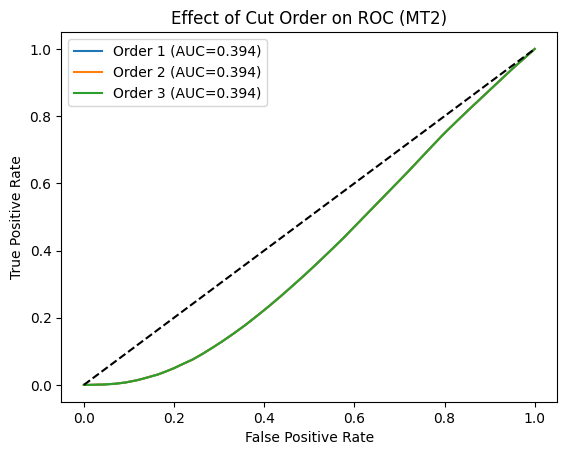

In [115]:
### 7.4 (with AI assistance)
def roc_order_effect(df, cut_orders, feature="MT2", label="signal", mode="greater", n_points=200):

    plt.figure()

    # Loop over each ordering of cuts
    for i, cuts in enumerate(cut_orders):

        df_cut = df.copy()

        # Apply cuts in different order
        for feature_cut, xc in cuts:
            # Apply cut depending on direction
            if mode == "greater":
                df_cut = df_cut[df_cut[feature_cut] > xc]
            elif mode == "less":
                df_cut = df_cut[df_cut[feature_cut] < xc]

        # ROC on same feature
        thresholds = np.linspace(
            df_cut[feature].min(),
            df_cut[feature].max(),
            n_points
        )

        # Compute TPR and FPR for ROC curve
        fpr, tpr = get_efficiencies(df_cut, feature, label, thresholds, mode)

        # Compute AUC
        auc = auc_manual(fpr, tpr)

        # Plot ROC curve for this cut order
        plt.plot(fpr, tpr, label=f"Order {i+1} (AUC={auc:.3f})")

    # Add reference line
    plt.plot([0, 1], [0, 1], "k--")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Effect of Cut Order on ROC ({feature})")
    plt.legend()
    plt.show()

cut_orders = [
    [("MET", 0.4), ("M_R", 0.6), ("MT2", 0.5)],
    [("MT2", 0.5), ("M_R", 0.6), ("MET", 0.4)],
    [("M_R", 0.6), ("MET", 0.4), ("MT2", 0.5)]
]

roc_order_effect(df, cut_orders, feature="MT2", label="signal")

All of the ROC curves are the same with the same area under curve. No matter the order of cuts, the final selected dataset is identical.

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.2

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.3

Draw the ROC curve for $F_n$. 

### Exercise 8.4

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [45]:
### 8.1 (with AI assistance)
# Selected features
features = ["MET", "M_R", "MT2"]

## Split dataset into signal (class 1) and background (class 0)
signal = df[df["signal"] == 1]
background = df[df["signal"] == 0]

# Extract feature matrices for each class
X_s = signal[features].values
X_b = background[features].values

# Compute mean vectors for signal and background
m_s = np.mean(X_s, axis=0).reshape(-1, 1)
m_b = np.mean(X_b, axis=0).reshape(-1, 1)

# Between-class scatter
S_B = (m_s - m_b) @ (m_s - m_b).T

# Within-class scatter
S_W = np.zeros((len(features), len(features)))

# Accumulate scatter for signal class
for x in X_s:
    x = x.reshape(-1, 1)
    S_W += (x - m_s) @ (x - m_s).T

# Accumulate scatter for background class
for x in X_b:
    x = x.reshape(-1, 1)
    S_W += (x - m_b) @ (x - m_b).T

print("S_B:\n", S_B)
print("S_W:\n", S_W)

S_B:
 [[0.59114029 0.25872053 0.10531678]
 [0.25872053 0.11323253 0.04609331]
 [0.10531678 0.04609331 0.0187631 ]]
S_W:
 [[3076060.48106419  408518.18760377  651243.77237041]
 [ 408518.18760377 1836706.24419459 -240318.51575328]
 [ 651243.77237041 -240318.51575328 3668259.49047798]]


- S_B: separation between signal and background means
- S_W: spread within each class

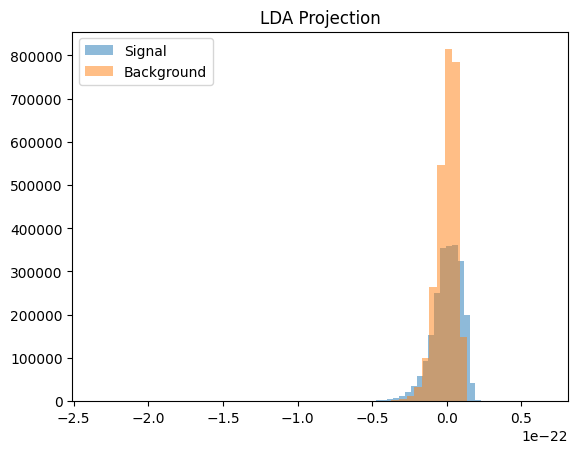

In [50]:
### 8.2 (with AI assistance)
# Standardize features separately for signal and background
# This ensures each feature has mean 0 and variance 1
X_s = (X_s - X_s.mean(axis=0)) / X_s.std(axis=0)
X_b = (X_b - X_b.mean(axis=0)) / X_b.std(axis=0)

# Compute class mean vectors after normalization
m_s = np.mean(X_s, axis=0).reshape(-1, 1)
m_b = np.mean(X_b, axis=0).reshape(-1, 1)

# Initialize within-class scatter matrix
S_W = np.zeros((X_s.shape[1], X_s.shape[1]))

# Accumulate within-class scatter for signal
for x in X_s:
    x = x.reshape(-1, 1)
    S_W += (x - m_s) @ (x - m_s).T

# Accumulate within-class scatter for background
for x in X_b:
    x = x.reshape(-1, 1)
    S_W += (x - m_b) @ (x - m_b).T

# Add small regularization term for numerical stability
S_W += 1e-6 * np.eye(S_W.shape[0])

w = np.linalg.pinv(S_W) @ (m_s - m_b)
w = w.flatten()

# Project data onto LDA direction
F_s = X_s @ w
F_b = X_b @ w

plt.hist(F_s, bins=50, alpha=0.5, label="Signal")
plt.hist(F_b, bins=50, alpha=0.5, label="Background")
plt.legend()
plt.title("LDA Projection")
plt.show()

The LDA projection collapses multi-dimensional observables into a single discriminant maximizing class separation.

In [52]:
### 8.3 (with AI assistance)
def roc(scores, y):
    # Replace NaNs with 0 to avoid errors in sorting or comparisons
    scores = np.nan_to_num(scores)

    # Sort scores in descending order (highest score = most signal-like first)  
    idx = np.argsort(-scores)
    # Reorder true labels to match sorted scores
    y = y[idx]

    # Count total positives (signal) and negatives (background) 
    P = np.sum(y == 1)
    N = np.sum(y == 0)

    # Compute cumulative true positive rate (TPR)
    # TPR = fraction of signal correctly identified as threshold decreases
    tpr = np.cumsum(y == 1) / P
    # Compute cumulative false positive rate (FPR)
    # FPR = fraction of background incorrectly classified as signal
    fpr = np.cumsum(y == 0) / N

    # Add starting point (0,0) to ROC curve for proper plotting
    fpr = np.concatenate([[0], fpr])
    tpr = np.concatenate([[0], tpr])

    return fpr, tpr

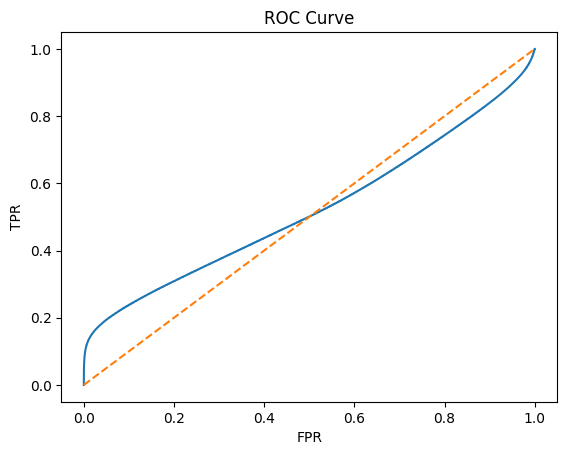

In [54]:
### Run
scores = np.concatenate([F_s, F_b])
y = np.concatenate([np.ones(len(F_s)), np.zeros(len(F_b))])

fpr, tpr = roc(scores, y)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

In [55]:
### 8.4 (with AI assistance)
def max_significance(scores, y):
    # Generate a range of possible threshold values across the score distribution
    thresholds = np.linspace(scores.min(), scores.max(), 300)

    # Track the best (maximum) significance and corresponding threshold
    best_z = 0
    best_t = 0

    # Loop over all candidate thresholds
    for t in thresholds:

        # True positives: signal events correctly classified above threshold
        S = np.sum((scores > t) & (y == 1))

        # False positives: background events incorrectly classified as signal
        B = np.sum((scores > t) & (y == 0))

        # Skip case where no events pass the cut
        if S + B == 0:
            continue

        # Significance metric (signal over statistical fluctuation of S+B)
        # Common approximation: Z = S / sqrt(S + B)
        z = S / np.sqrt(S + B)

        # Update best threshold if this one improves significance
        if z > best_z:
            best_z = z
            best_t = t

    return best_z, best_t

In [56]:
### Run
best_z, best_t = max_significance(scores, y)

print("Max significance:", best_z)
print("Best threshold:", best_t)

Max significance: 1023.1483617007555
Best threshold: -1.3172561597599884e-22
